In [26]:
!pip install seaborn aeon

  Using cached aeon-1.3.0-py3-none-any.whl.metadata (21 kB)
Using cached aeon-1.3.0-py3-none-any.whl (6.5 MB)
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ----------------------------- ---------- 2.1/2.8 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 9.7 MB/s  0:00:00
   ---------------------------------------- 0.0/30.3 MB ? eta -:--:--
   ---- ----------------------------------- 3.1/30.3 MB 13.2 MB/s eta 0:00:03
   ----------- ---------------------------- 8.7/30.3 MB 20.7 MB/s eta 0:00:02
   ---------------- ----------------------- 12.6/30.3 MB 22.5 MB/s eta 0:00:01
   --------------------- ------------------ 16.5/30.3 MB 20.0 MB/s eta 0:00:01
   ----------------------------- ---------- 22.5/30.3 MB 22.0 MB/s eta 0:00:01
   ------------------------------------ --- 28.0/30.3 MB 22.5 MB/s eta 0:00:01
   ---------------------------------------- 30.3/30.3 MB 21.


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import sqlite3
import pandas as pd
from ana_utils import *
import numpy as np
from deepsig import aso
from tqdm.auto import tqdm
import os
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors

c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
METRIC = "root_mean_squared_error" 
PRETTY_METRIC = "RMSE"
larger_is_better = False 

best_color = "Magma" #"cyan"
worst_color = "white"

# DeepSig
debug = False
seed = 1234
np.random.seed(seed)
min_eps_thr = 0.2
if debug:
    n_sig = 5
    n_workers = 1
else:
    n_sig = 1000
    n_workers = os.cpu_count() 

In [3]:
def compute_mean(s: pd.Series)-> pd.Series:
    if METRIC == "r2_score" and corrected:
        return s.apply(
            lambda xs: np.nanmean([x if x is not None else 0 for x in xs])
        )
    return s.apply(
        lambda xs: np.nanmean([x for x in xs]) if None not in xs else np.nan
    )

_magma = cm.get_cmap("magma")


def _magma_rgba(pct: float):
    normalized = max(0.0, min(1.0, pct / 100.0))
    return _magma(normalized)


def _rgba_to_hex(rgba):
    return mcolors.to_hex(rgba, keep_alpha=False)[1:].upper()


def _relative_luminance(r, g, b):
    """
    WCAG relative luminance.
    Input RGB in [0,1]
    """
    def f(c):
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4

    r_lin, g_lin, b_lin = f(r), f(g), f(b)
    return 0.2126 * r_lin + 0.7152 * g_lin + 0.0722 * b_lin


def _font_color_from_rgba(rgba):
    r, g, b, _ = rgba
    lum = _relative_luminance(r, g, b)
    return "white" if lum < 0.5 else "black"

C:\Users\poehlmann\AppData\Local\Temp\ipykernel_29056\2886983685.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _magma = cm.get_cmap("magma")


In [4]:
conn_vimet = sqlite3.connect(vimet_path)
df_vimet = pd.read_sql(f"SELECT results.model as model, search_space_name as Model, {METRIC}, mean_squared_error, data_config_hash, data_id FROM results join search_spaces on results.search_space_hash == search_spaces.hash_key", conn_vimet)
conn_vimet.close()
df_vimet['Model'] = df_vimet['Model'].str.replace(r'^(.*?)_(.*)$', r'\1(\2)', regex=True)
df_vimet = convert_listlike_cols(df_vimet)

# remove duplicates
df_vimet = df_vimet.drop_duplicates(subset=['Model', 'data_id', 'data_config_hash'], keep='first')

# keep only models with a failure rate below 20% (anything above that cannot be used for meaningfull comparisons)
successrate_threshold = len(df_vimet["data_id"].unique()) * 0.8
vc = df_vimet['Model'].value_counts()
df_vimet = df_vimet[df_vimet['Model'].isin(vc[vc >= successrate_threshold].index)]

df_vimet['Model'].value_counts()

root_mean_squared_error
mean_squared_error


Model
AdaBoost               102
Bagging                102
MeanModel              102
AutoGluon(30min)       102
AutoGluon(2h)          102
AutoGluon(1h)          102
AutoGluon(10min)       102
XGBoost                102
RandomForest           102
RidgeRegressor         102
SGD                    102
MLP                    102
PassiveAggressive      102
M5                     102
LightGBM               102
PartialLeastSquares    102
Lasso                  102
KNN                    102
Huber                  102
LassoLars              102
GradientBoosting       102
ExtraTrees             102
ElasticNet             102
Dummy                  102
DecisionTree           102
BayesianRidge          102
MedianModel            102
AutoGluon(5min)        100
CatBoost               100
Name: count, dtype: int64

In [5]:
conn_ctr = sqlite3.connect(ctr_path)
df_ctr = pd.read_sql(f"SELECT results.model as model, search_space_name as Model, {METRIC}, mean_squared_error, data_config_hash, data_id FROM results join search_spaces on results.search_space_hash == search_spaces.hash_key", conn_ctr)
conn_ctr.close()
df_ctr['Model'] = df_ctr['Model'].str.replace(r'^(.*?)_(.*)$', r'\1(\2)', regex=True)
df_ctr = convert_listlike_cols(df_ctr)

# remove duplicates
df_ctr = df_ctr.drop_duplicates(subset=['Model', 'data_id', 'data_config_hash'], keep='first')

# keep only models with a failure rate below 20% (anything above that cannot be used for meaningfull comparisons)
successrate_threshold = len(df_ctr["data_id"].unique()) * 0.8
vc = df_ctr['Model'].value_counts()
df_ctr = df_ctr[df_ctr['Model'].isin(vc[vc >= successrate_threshold].index)]

df_ctr['Model'].value_counts()

root_mean_squared_error
mean_squared_error


Model
AdaBoost               35
LightGBM               35
AutoGluon(1h)          35
AutoGluon(30min)       35
AutoGluon(1min)        35
XGBoost                35
GaussianProcess        35
SGD                    35
RidgeRegressor         35
PassiveAggressive      35
PartialLeastSquares    35
Bagging                35
MeanModel              35
MedianModel            35
ElasticNet             35
CatBoost               35
BayesianRidge          35
DecisionTree           35
Dummy                  35
Lasso                  35
AutoGluon(2h)          35
Huber                  35
GradientBoosting       35
KNN                    35
ExtraTrees             34
AutoGluon(5min)        34
AutoGluon(10min)       34
CubistModel            34
LARS                   34
LassoLars              34
RandomForest           33
M5                     33
MLP                    33
Tweedie                29
Name: count, dtype: int64

In [6]:
# get common model values
common = set(df_ctr["Model"]).intersection(df_vimet["Model"])
removed_models = set(df_ctr["Model"]) - common

# filter both dataframes
df_ctr = df_ctr[df_ctr["Model"].isin(common)].copy()
df_vimet = df_vimet[df_vimet["Model"].isin(common)].copy()
df_ctr['Model'].value_counts()
removed_models

{'AutoGluon(1min)', 'CubistModel', 'GaussianProcess', 'LARS', 'Tweedie'}

In [9]:
def calc_statistics(df, aggregate=True):
    groups = df.groupby(by=["data_config_hash", "data_id"])
    group_collection = []
    all_models = df["Model"].unique().tolist() + ["AutoGluon(best)", "AutoGluon(worst)", "AutoGluon/Mean(best)"]
    baselines = ["AutoGluon(best)", "AutoGluon(30min)", "MeanModel", "AutoGluon(worst)", "AutoGluon/Mean(best)"]
    beat_baseline = {b: {m: 0 for m in all_models} for b in baselines} # baseline: {model: wins}
    
    for (hash, data_id), group_df in tqdm(groups):
        # Add AutoGluon(best) to group
        if larger_is_better:
            best_idx = (
                group_df.loc[group_df["model"] == "AutoGluon", "avg_metric"]
                .idxmax()
            )
            worst_idx = (
                group_df.loc[group_df["model"] == "AutoGluon", "avg_metric"]
                .idxmin()
            )
        else:
            best_idx = (
                group_df.loc[group_df["model"] == "AutoGluon", "avg_metric"]
                .idxmin()
            )
            worst_idx = (
                group_df.loc[group_df["model"] == "AutoGluon", "avg_metric"]
                .idxmax()
            )
            # AG+Mean(Best)
            best_mean_ag_idx = (
                group_df.loc[group_df["model"].isin(["AutoGluon", "MeanModel"]), "avg_metric"]
                .idxmin()
            )
        best_ag_model = group_df.loc[best_idx].copy()
        worst_ag_model = group_df.loc[worst_idx].copy()
        best_mean_ag_model = group_df.loc[best_mean_ag_idx].copy()
        best_ag_model["Model"] = "AutoGluon(best)"
        worst_ag_model["Model"] = "AutoGluon(worst)"
        best_mean_ag_model["Model"] = "AutoGluon/Mean(best)"


        # ag_id = group_df[group_df["model"] == "AutoGluon"].index[0]
        # median_ag_model = group_df.loc[ag_id].copy() # Load Template (Doesnt matter which id as long as its AutoGluon)
        # median_ag_model["Model"] = "AutoGluon(median)"
        # median_ag_model["avg_metric"] = group_df.loc[group_df["model"] == "AutoGluon", "avg_metric"].median() 
        # median_ag_model["MSE"] = group_df.loc[group_df["model"] == "AutoGluon", "MSE"].median()
        group_df = pd.concat([group_df, pd.DataFrame([best_ag_model]), pd.DataFrame([worst_ag_model]), pd.DataFrame([best_mean_ag_model])], ignore_index=True)

        # Calculate Significant Wins against selected baselines
        model_scores = group_df[["Model", METRIC]]
        model_scores = model_scores.set_index(model_scores["Model"])
        model_scores_dict = model_scores[METRIC].to_dict()
        for baseline_model in tqdm(baselines, desc="DeepSig Significance Tests"):
            if baseline_model not in model_scores_dict:
                continue
            for model in model_scores_dict.keys():
                if larger_is_better:
                    min_eps = aso(model_scores_dict[model], model_scores_dict[baseline_model], seed=seed, show_progress=False, num_bootstrap_iterations=n_sig, num_jobs=n_workers)
                else:
                    min_eps = aso(-np.array(model_scores_dict[model]), -np.array(model_scores_dict[baseline_model]), seed=seed, show_progress=False, num_bootstrap_iterations=n_sig, num_jobs=n_workers)
                if min_eps < min_eps_thr:
                    beat_baseline[baseline_model][model] += 1
        
        # Set Missing Entries to 0 - they likely crashed
        group_df = group_df.set_index(group_df["Model"])
        group_df = group_df[~group_df.index.duplicated(keep="first")]
        group_df = group_df.drop(["Model"], axis=1)
        if METRIC == "r2_score":
            group_df = group_df.reindex(all_models, fill_value=0)
        else:
            if larger_is_better:
                group_df = group_df.reindex(all_models)
                group_df.loc[group_df["avg_metric"].isna(), "avg_metric"] = group_df["avg_metric"].min()
            else:
                group_df = group_df.reindex(all_models)
                group_df.loc[group_df["avg_metric"].isna(), "avg_metric"] = group_df["avg_metric"].max()
        group_df["Model"] = group_df.index
        group_df = group_df.reset_index(drop=True)

        MSE_mean_model = group_df.loc[group_df["Model"] == "MeanModel", "MSE"].iloc[0]
        MSE_AG_best = group_df.loc[group_df["Model"] == "AutoGluon(best)", "MSE"].iloc[0]
        MSE_AG_30min = group_df.loc[group_df["Model"] == "AutoGluon(30min)", "MSE"].iloc[0]
        group_df["R2 (mean)"] = 1 - (group_df["MSE"] / MSE_mean_model)
        group_df["R2 (AG best)"] = 1 - (group_df["MSE"] / MSE_AG_best)
        group_df["R2 (AG 30min)"] = 1 - (group_df["MSE"] / MSE_AG_30min)
        if group_df["R2 (mean)"].median() < -1000:
            print("Warning: Extremely low R2 detected, likely due to failures")
        
        if larger_is_better:
            best = group_df["avg_metric"].max()
        else:
            best = group_df["avg_metric"].min()

        median = group_df["avg_metric"].median()
        if METRIC == "r2_score":
            if best <= 0.001:
                group_df["normalized_metric"] = 0 # If all fail, all fail simple as that
            else:
                group_df["normalized_metric"] = (group_df["avg_metric"] - median) / max(best-median, 1e-5)
        else:
            if larger_is_better:
                group_df["normalized_metric"] = (group_df["avg_metric"] - median) / max(best-median, 1e-5) #TODO what happens when negative
            else:
                group_df["normalized_metric"] = (group_df["avg_metric"] - best) / max(median-best, 1e-5)

        group_df["rounded_rank"] = group_df["normalized_metric"].rank(method="dense", ascending=not larger_is_better)
        group_df["losses"] = (group_df["rounded_rank"] == group_df["rounded_rank"].max()) & (group_df["rounded_rank"] != group_df["rounded_rank"].min())
        group_df["true wins"] = (group_df["rounded_rank"] == group_df["rounded_rank"].min()) & (group_df["rounded_rank"] != group_df["rounded_rank"].max())
        
        # Precision ~ How many models are better that arent the best
        better_models_cnt = (group_df["rounded_rank"] - 1).clip(lower=1) # Rank 2 & Rank 1 means precision of 1 
        worse_models_cnt = (group_df["rounded_rank"].max() - group_df["rounded_rank"]) # True Negatives
        group_df["precision"] = 1/(1 + (better_models_cnt -1)) # FP = #better models - #TP
        group_df["accuracy"] = (1 + worse_models_cnt) / (1 + better_models_cnt - 1 + worse_models_cnt + 0) # There are no False Negatives

    
        group_df_wo_ag = group_df[group_df["model"] != "AutoGluon"]
        if larger_is_better:
            best_wo_ag = group_df_wo_ag["avg_metric"].max() # TODO what if not Larger is better?
        else:
            best_wo_ag = group_df_wo_ag["avg_metric"].min()
        median_wo_ag = group_df_wo_ag["avg_metric"].median()
        if METRIC == "r2_score":
            assert larger_is_better, "R2 should always be larger is better"
            if best_wo_ag <= 0.001:
                group_df["normalized_metric_wo_ag"] = 0 # If all fail, all fail simple as that
            else:
                group_df["normalized_metric_wo_ag"] = (group_df["avg_metric"] - median_wo_ag) / max(best_wo_ag-median_wo_ag, 1e-5)
                raise NotImplementedError("Check if by best_wo_ag or median_wo_ag")
                group_df["normalized_metric_wo_ag_sig"] = (group_df["avg_metric"] - median_wo_ag) / best_wo_ag
        else:
            if larger_is_better:
                group_df["normalized_metric_wo_ag"] = (group_df["avg_metric"] - median_wo_ag) / max(best_wo_ag-median_wo_ag, 1e-5) #TODO what happens when negative
                raise NotImplementedError("Check if by best_wo_ag or median_wo_ag")
                group_df["normalized_metric_wo_ag_sig"] = (group_df["avg_metric"] - median_wo_ag) / best_wo_ag
            else:
                group_df["normalized_metric_wo_ag"] = (group_df["avg_metric"] - best_wo_ag) / max(median_wo_ag-best_wo_ag, 1e-5) 
                group_df["normalized_metric_wo_ag_sig"] = (group_df["avg_metric"] - best_wo_ag) / best_wo_ag
        

        for contestant in baselines:
            ag_perf = group_df[group_df["Model"] == contestant]["avg_metric"].iloc[0]
            group_df[f"victories_against_{contestant}"] = group_df["avg_metric"] > ag_perf if larger_is_better else group_df["avg_metric"] < ag_perf
    
        group_df = group_df.reset_index(drop=False)

        group_collection.append(group_df)
    df_ = pd.concat(group_collection)
    if not aggregate:
        return df_
    
    df_ = df_.groupby(by=["Model"]).agg(
        Avg_R2 = ("avg_metric", "mean"),
        Rank = ("rounded_rank", "mean"),
        R2_mean = ("R2 (mean)", lambda s: s.clip(lower=-1).mean()),
        R2_AG_best = ("R2 (AG best)", lambda s: s.clip(lower=-1).mean()),
        R2_AG_30min = ("R2 (AG 30min)", lambda s: s.clip(lower=-1).mean()),
        Norm_Metric = ("normalized_metric", lambda s: s.clip(**({"upper":1} if not larger_is_better else {"lower":0})).mean()), # Clip performance to 0/1 to avoid ruining average by extreme outliers
        Norm_Metric_min=("normalized_metric", "min"),
        Norm_Metric_max=("normalized_metric", "max"),
        Norm_Metric_wo_AG = ("normalized_metric_wo_ag", lambda s: s.clip(**({"upper":1} if not larger_is_better else {"lower":0})).mean()), # Clip performance to 0/1 to avoid ruining average by extreme outliers
        Norm_Metric_wo_AG_min = ("normalized_metric_wo_ag", "min"),
        Norm_Metric_wo_AG_max = ("normalized_metric_wo_ag", "max"),
        Norm_Metric_wo_AG_sig = ("normalized_metric_wo_ag_sig", lambda s: s.clip(**({"upper":1} if not larger_is_better else {"lower":0})).mean()), # Clip performance to 0/1 to avoid ruining average by extreme outliers
        Wins_Against_AG_30min = ("victories_against_AutoGluon(30min)", "sum"),
        # Wins_Against_AG_median = ("victories_against_AutoGluon(median)", "sum"),
        Wins_Against_AG_best = ("victories_against_AutoGluon(best)", "sum"),
        Wins_Against_AG_worst = ("victories_against_AutoGluon(worst)", "sum"),
        Wins_Against_MeanModel = ("victories_against_MeanModel", "sum"),
        Wins_Against_AG_MeanModel = ("victories_against_AutoGluon/Mean(best)", "sum"),
        Progress_Identification_MeanModel = ("R2 (mean)", lambda s: (s > 0.3).sum()),
        Progress_Identification_AG_best = ("R2 (AG best)", lambda s: (s > 0.3).sum()),
        Progress_Identification_AG_30min = ("R2 (AG 30min)", lambda s: (s > 0.3).sum()),
        Losses_tied = ("losses", "sum"),
        Precision = ("precision", "mean"),
        Accuracy = ("accuracy", "mean"),
    )

    sig_wins = pd.DataFrame(beat_baseline).fillna(0).astype(int)
    sig_wins = sig_wins.rename({col: f"Sig Wins against {col}" for col in sig_wins.columns}, axis=1) 
    df_ = df_.join(sig_wins)
    print(group_df[METRIC])
    return df_.sort_values(by=["Norm_Metric_wo_AG", "Rank"])

In [10]:
df_vimet["avg_metric"] = compute_mean(df_vimet[METRIC])
df_vimet["MSE"] = compute_mean(df_vimet["mean_squared_error"])
df_vimet = df_vimet.dropna(subset=["avg_metric"], how='all')

df_vimet_ready = calc_statistics(df_vimet)

df_ctr["avg_metric"] = compute_mean(df_ctr[METRIC])
df_ctr["MSE"] = compute_mean(df_ctr["mean_squared_error"])
df_ctr = df_ctr.dropna(subset=["avg_metric"], how='all')

df_ctr_ready = calc_statistics(df_ctr)


df_vimet_ready[["Norm_Metric_wo_AG_sig", "Rank", "Precision", "Accuracy", "Sig Wins against AutoGluon(best)", "Sig Wins against MeanModel"]]

  0%|          | 0/102 [00:00<?, ?it/s]c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encountered in violation ratio.")
  1%|          | 1/102 [02:16<3:49:11, 136.16s/it]c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encountered in violation ratio.")
  2%|▏         | 2/102 [03:58<3:14:01, 116.42s/it]c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encountered in violation ratio.")
  3%|▎         | 3/102 [05:47<3:06:17, 112.90s/it]c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encou

c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encountered in violation ratio.")
 56%|█████▌    | 57/102 [2:53:23<1:31:05, 121.46s/it]c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encountered in violation ratio.")
 57%|█████▋    | 58/102 [2:55:28<1:29:45, 122.39s/it]c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encountered in violation ratio.")
 58%|█████▊    | 59/102 [2:57:31<1:27:45, 122.45s/it]c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encountered in violation ratio.")
 

0     [54.89841273286735, 128.17803104697256, 86.094...
1     [50.75741396497444, 99.52033594536098, 81.5169...
2     [63.669253142632876, 109.64254674092906, 102.9...
3     [74.68726445527498, 102.95810810967654, 78.475...
4     [78.30210542958527, 106.40379154101834, 69.057...
5     [69.20493896259569, 97.71686333183062, 93.8730...
6     [239.51453223939973, 242.08025965558488, 110.2...
7     [63.6558712507258, 100.0277176502567, 68.55237...
8     [56.736139470951194, 93.39052267397463, 88.108...
9     [64.52087465574276, 107.01341341997083, 212.41...
10    [103.84929760541513, 141.77977808812986, 159.6...
11    [54.79606050674472, 110.78075421568288, 86.638...
12    [67.01168706510792, 107.03983776724813, 113.27...
13    [79.76285667302905, 116.10288717756984, 530.98...
14    [60.13233989750015, 107.09057080753894, 82.000...
15    [56.739656400511144, 72.57183293951572, 86.025...
16    [303.3159156177792, 83.63753788692712, 94.4157...
17    [179.99470209122032, 3488.2231811286506, 3

  0%|          | 0/35 [00:00<?, ?it/s]c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encountered in violation ratio.")
  3%|▎         | 1/35 [01:50<1:02:34, 110.43s/it]c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encountered in violation ratio.")
  6%|▌         | 2/35 [03:39<1:00:26, 109.90s/it]c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encountered in violation ratio.")
  9%|▊         | 3/35 [05:27<58:02, 108.83s/it]  c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encounter

0     [0.11023282541472668, 0.13073776612604765, 0.1...
1     [0.13482335302866666, 0.15742105919146365, 0.1...
2     [0.11838439603388086, 0.14007591296194802, 0.1...
3     [0.12633891549849036, 0.14312428958260717, 0.1...
4     [0.1825776102994101, 0.2079123103857534, 0.191...
5     [0.11838202497781135, 0.14007538643816742, 0.1...
6     [0.0932934277276493, 0.12327002258439558, 0.09...
7     [0.10454347264303734, 0.13217374004793347, 0.1...
8     [0.21322047103344013, 0.2210533726733198, 0.21...
9     [0.10096616570012855, 0.12641148456378734, 0.1...
10    [0.12294799350511315, 0.14427230724700446, 0.1...
11    [0.1184984158880133, 0.14006193940243242, 0.12...
12    [0.11853969174601114, 0.14006365843976076, 0.1...
13    [0.09551558682082564, 0.11841987054388026, 0.1...
14    [0.1825776102994101, 0.2079123103857534, 0.191...
15    [0.1832404867605431, 0.2084699418147578, 0.190...
16    [0.11873487485004663, 0.1412816812826262, 0.13...
17    [0.23044328598381483, 0.2439111017294241, 

,Norm_Metric_wo_AG_sig,Rank,Precision,Accuracy,Sig Wins against AutoGluon(best),Sig Wins against MeanModel
Model,,,,,,
AutoGluon/Mean(best),0.015183,2.392157,0.825526,0.965613,0,65
AutoGluon(best),0.022666,2.598039,0.799242,0.958908,0,65
AutoGluon(30min),0.067553,5.333333,0.458688,0.873749,0,57
AutoGluon(10min),0.069488,5.549020,0.439940,0.865692,0,60
AutoGluon(1h),0.086916,6.480392,0.445739,0.832693,0,55
AutoGluon(5min),0.102029,6.656863,0.393630,0.824604,0,60
ExtraTrees,0.079877,6.960784,0.328692,0.813297,1,59
AutoGluon(2h),0.110647,7.529412,0.359311,0.793806,0,53
RandomForest,0.088776,7.431373,0.261356,0.797822,0,56


In [11]:
def bold_if(value, best_value):
    if isinstance(value, int):
        if value == best_value:
            return f"\\textbf{{{value}}}"
        else:
            return f"{value}"
    else: 
        if value == best_value:
            return f"\\textbf{{{value:.2f}}}"
        else:
            return f"{value:.2f}"


def prepare_table(df, ds_count):
    def pretty(x, value_name, color=True, appendix_name=None):
        prefix = ""
        best_val = absolute_best[value_name] 
        worst_val = absolute_worst[value_name]
        content = bold_if(x[value_name], best_entries[value_name]) 
        if appendix_name is not None:
            content += f" ({bold_if(x[appendix_name], best_entries[appendix_name])})"
        if color:
            if best_val > worst_val:
                pct = int(100 * (x[value_name] - worst_val) / (best_val - worst_val)) if best_val != worst_val else 0
            else:
                pct = 100 - int(100 * (x[value_name] - best_val) / (worst_val - best_val)) if best_val != worst_val else 0
            
            if best_color == "Magma":
                rgba = _magma_rgba(pct)
                hex_color = _rgba_to_hex(rgba)
                font_color = _font_color_from_rgba(rgba)
                return rf"\cellcolor[HTML]{{{hex_color}}}\textcolor{{{font_color}}}{{{content}}}"
            
            prefix = rf"\cellcolor{{{best_color}!{pct}!{worst_color}}} "
        return prefix + content
    df_ctr_ready = df.copy()
    best_entries = {
        "Norm_Metric_wo_AG_sig": df_ctr_ready["Norm_Metric_wo_AG_sig"].max() if larger_is_better else df_ctr_ready["Norm_Metric_wo_AG_sig"].min(),
        "Rank": df_ctr_ready["Rank"].min(),
        "Precision": df_ctr_ready["Precision"].max(),
        "Accuracy": df_ctr_ready["Accuracy"].max(),
        "Sig Wins against AutoGluon(30min)": df_ctr_ready["Sig Wins against AutoGluon(30min)"].max(),
        # "Sig Wins against AutoGluon(median)": df_ctr_ready["Sig Wins against AutoGluon(median)"].max(),
        "Sig Wins against AutoGluon(best)": df_ctr_ready["Sig Wins against AutoGluon(best)"].max(),
        "Sig Wins against AutoGluon(worst)": df_ctr_ready["Sig Wins against AutoGluon(worst)"].max(),
        "Sig Wins against MeanModel": df_ctr_ready["Sig Wins against MeanModel"].max(),
        "Sig Wins against AutoGluon/Mean(best)": df_ctr_ready["Sig Wins against AutoGluon/Mean(best)"].max(),

        "Wins_Against_AG_best": df_ctr_ready["Wins_Against_AG_best"].max(),
        "Wins_Against_AG_worst": df_ctr_ready["Wins_Against_AG_worst"].max(),
        # "Wins_Against_AG_median": df_ctr_ready["Wins_Against_AG_median"].max(),
        "Wins_Against_AG_30min": df_ctr_ready["Wins_Against_AG_30min"].max(),
        "Wins_Against_MeanModel": df_ctr_ready["Wins_Against_MeanModel"].max(),
        "Wins_Against_AG_MeanModel": df_ctr_ready["Wins_Against_AG_MeanModel"].max(),

    }

    worst_entries = {
        "Norm_Metric_wo_AG_sig": df_ctr_ready["Norm_Metric_wo_AG_sig"].min() if larger_is_better else df_ctr_ready["Norm_Metric_wo_AG_sig"].max(),
        "Rank": df_ctr_ready["Rank"].max(),
        "Precision": df_ctr_ready["Precision"].min(),
        "Accuracy": df_ctr_ready["Accuracy"].min(),
        "Sig Wins against AutoGluon(30min)": df_ctr_ready["Sig Wins against AutoGluon(30min)"].min(),
        # "Sig Wins against AutoGluon(median)": df_ctr_ready["Sig Wins against AutoGluon(median)"].min(),
        "Sig Wins against AutoGluon(best)": df_ctr_ready["Sig Wins against AutoGluon(best)"].min(),
        "Sig Wins against AutoGluon(worst)": df_ctr_ready["Sig Wins against AutoGluon(worst)"].min(),
        "Sig Wins against MeanModel": df_ctr_ready["Sig Wins against MeanModel"].min(),
        "Sig Wins against AutoGluon/Mean(best)": df_ctr_ready["Sig Wins against AutoGluon/Mean(best)"].min(),
        "Wins_Against_AG_best": df_ctr_ready["Wins_Against_AG_best"].min(),
        # "Wins_Against_AG_median": df_ctr_ready["Wins_Against_AG_median"].min(),
        "Wins_Against_AG_30min": df_ctr_ready["Wins_Against_AG_30min"].min(),
        "Wins_Against_MeanModel": df_ctr_ready["Wins_Against_MeanModel"].min(),
        "Wins_Against_AG_MeanModel": df_ctr_ready["Wins_Against_AG_MeanModel"].min(),
    }

    absolute_best = {
        "Norm_Metric_wo_AG_sig": 1 if larger_is_better else 0,
        "Rank": 0,
        "Precision": 1,
        "Accuracy": 1,
        "Sig Wins against AutoGluon(30min)": ds_count,
        # "Sig Wins against AutoGluon(median)": ds_count,
        "Sig Wins against AutoGluon(best)": ds_count,
        "Sig Wins against AutoGluon(worst)": ds_count,
        "Sig Wins against MeanModel": ds_count,
        "Sig Wins against AutoGluon/Mean(best)": ds_count,

        "Wins_Against_AG_best": ds_count,
        # "Wins_Against_AG_median": ds_count,
        "Wins_Against_AG_30min": ds_count,
        "Wins_Against_MeanModel": ds_count,
        "Wins_Against_AG_MeanModel": ds_count,
    }

    absolute_worst = {
        "Norm_Metric_wo_AG_sig": 0 if larger_is_better else 1,
        "Rank": len(df_ctr_ready),
        "Precision": 0,
        "Accuracy": 0,
        "Sig Wins against AutoGluon(30min)": 0,
        # "Sig Wins against AutoGluon(median)": 0,
        "Sig Wins against AutoGluon(best)": 0,
        "Sig Wins against AutoGluon(worst)": 0,
        "Sig Wins against MeanModel": 0,
        "Sig Wins against AutoGluon/Mean(best)": 0,

        "Wins_Against_AG_best": 0,
        # "Wins_Against_AG_median": 0,
        "Wins_Against_AG_30min": 0,
        "Wins_Against_MeanModel": 0,
        "Wins_Against_AG_MeanModel": 0,
    }

    df_ctr_ready[f"Norm {PRETTY_METRIC}"] = df_ctr_ready.apply(lambda x: f"{pretty(x, 'Norm_Metric_wo_AG_sig')}", axis=1)
    df_ctr_ready["Avg Rank"] = df_ctr_ready.apply(lambda x: f"{pretty(x, 'Rank')}", axis=1)
    df_ctr_ready["Precision"] = df_ctr_ready.apply(lambda x: f"{pretty(x, 'Precision')}", axis=1)
    df_ctr_ready["Accuracy"] = df_ctr_ready.apply(lambda x: f"{pretty(x, 'Accuracy')}", axis=1)
    df_ctr_ready["Wins (AG 30min)"] = df_ctr_ready.apply(lambda x: f"{pretty(x, 'Sig Wins against AutoGluon(30min)', appendix_name='Wins_Against_AG_30min')}", axis=1)
    # df_ctr_ready["Wins (AG Median)"] = df_ctr_ready.apply(lambda x: f"{pretty(x, 'Sig Wins against AutoGluon(median)', appendix_name='Wins_Against_AG_median')}", axis=1)
    df_ctr_ready["Wins (AG Best)"] = df_ctr_ready.apply(lambda x: f"{pretty(x, 'Sig Wins against AutoGluon(best)', appendix_name='Wins_Against_AG_best')}", axis=1) 
    df_ctr_ready["Wins (AG Worst)"] = df_ctr_ready.apply(lambda x: f"{pretty(x, 'Sig Wins against AutoGluon(worst)', appendix_name='Wins_Against_AG_worst')}", axis=1)
    df_ctr_ready["Wins (MeanModel)"] = df_ctr_ready.apply(lambda x: f"{pretty(x, 'Sig Wins against MeanModel', appendix_name='Wins_Against_MeanModel')}", axis=1)
    df_ctr_ready["Wins (AG/Mean)"] = df_ctr_ready.apply(lambda x: f"{pretty(x, 'Sig Wins against AutoGluon/Mean(best)', appendix_name='Wins_Against_AG_MeanModel')}", axis=1)

    # Remove useless comparisons
    if best_color == "Magma": 
        rgba = _magma_rgba(0)
        hex_color = _rgba_to_hex(rgba)
        font_color = _font_color_from_rgba(rgba)
        missing_value = rf"\cellcolor[HTML]{{{hex_color}}}\textcolor{{{font_color}}}{{\NA}}"
    else:
        missing_value = r"\NA"
    df_ctr_ready.loc[df_ctr_ready.index.str.contains("AutoGluon", na=False), "Wins (AG Best)"] = missing_value
    # df_ctr_ready.loc[df_ctr_ready.index.str.contains("AutoGluon(Median)", na=False, regex=False), "Wins (AG Median)"] = missing_value
    df_ctr_ready.loc[df_ctr_ready.index.str.contains("AutoGluon(30min)", na=False, regex=False), "Wins (AG 30min)"] = missing_value
    df_ctr_ready.loc[df_ctr_ready.index.str.contains("AutoGluon(worst)", na=False, regex=False), "Wins (AG Worst)"] = missing_value
    df_ctr_ready.loc[df_ctr_ready.index.str.contains("MeanModel", na=False), "Wins (MeanModel)"] = missing_value


    df_for_render = df_ctr_ready[[f"Norm {PRETTY_METRIC}", "Avg Rank", "Precision", "Accuracy", "Wins (AG Best)", "Wins (AG Worst)", "Wins (AG 30min)", "Wins (MeanModel)", "Wins (AG/Mean)"]] #  "Wins (AG Median)",
    return df_for_render
    
df_vimet_table = prepare_table(df_vimet_ready.sort_values(by=["Precision"], ascending=True), ds_count=102)
df_ctr_table = prepare_table(df_ctr_ready.sort_values(by=["Precision"], ascending=True), ds_count=35)
df_vimet_table

,Norm RMSE,Avg Rank,Precision,Accuracy,Wins (AG Best),Wins (AG Worst),Wins (AG 30min),Wins (MeanModel),Wins (AG/Mean)
Model,,,,,,,,,
SGD,\cellcolor[HTML]{000004}\textcolor{white}{1.00},\cellcolor[HTML]{1E1149}\textcolor{white}{28.04},\cellcolor[HTML]{03030F}\textcolor{white}{0.04},\cellcolor[HTML]{050416}\textcolor{white}{0.04},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)}
Huber,\cellcolor[HTML]{251255}\textcolor{white}{0.85},\cellcolor[HTML]{5C167F}\textcolor{white}{23.22},\cellcolor[HTML]{06051A}\textcolor{white}{0.05},\cellcolor[HTML]{440F76}\textcolor{white}{0.22},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)},\cellcolor[HTML]{000004}\textcolor{white}{1 (5)},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)},\cellcolor[HTML]{000004}\textcolor{white}{1 (4)},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)}
MLP,\cellcolor[HTML]{440F76}\textcolor{white}{0.79},\cellcolor[HTML]{681C81}\textcolor{white}{22.25},\cellcolor[HTML]{06051A}\textcolor{white}{0.06},\cellcolor[HTML]{51127C}\textcolor{white}{0.25},\cellcolor[HTML]{000004}\textcolor{white}{0 (1)},\cellcolor[HTML]{000004}\textcolor{white}{1 (5)},\cellcolor[HTML]{000004}\textcolor{white}{1 (2)},\cellcolor[HTML]{000004}\textcolor{white}{0 (7)},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)}
PassiveAggressive,\cellcolor[HTML]{681C81}\textcolor{white}{0.70},\cellcolor[HTML]{782281}\textcolor{white}{21.06},\cellcolor[HTML]{090720}\textcolor{white}{0.07},\cellcolor[HTML]{601880}\textcolor{white}{0.30},\cellcolor[HTML]{000004}\textcolor{white}{0 (1)},\cellcolor[HTML]{010106}\textcolor{white}{2 (11)},\cellcolor[HTML]{000004}\textcolor{white}{0 (1)},\cellcolor[HTML]{000004}\textcolor{white}{0 (7)},\cellcolor[HTML]{000004}\textcolor{white}{0 (1)}
ElasticNet,\cellcolor[HTML]{601880}\textcolor{white}{0.71},\cellcolor[HTML]{802582}\textcolor{white}{20.32},\cellcolor[HTML]{090720}\textcolor{white}{0.07},\cellcolor[HTML]{701F81}\textcolor{white}{0.33},\cellcolor[HTML]{000004}\textcolor{white}{0 (5)},\cellcolor[HTML]{010106}\textcolor{white}{2 (12)},\cellcolor[HTML]{000004}\textcolor{white}{0 (5)},\cellcolor[HTML]{1A1042}\textcolor{white}{13 (...,\cellcolor[HTML]{000004}\textcolor{white}{0 (5)}
Lasso,\cellcolor[HTML]{440F76}\textcolor{white}{0.79},\cellcolor[HTML]{701F81}\textcolor{white}{21.61},\cellcolor[HTML]{0B0924}\textcolor{white}{0.07},\cellcolor[HTML]{5C167F}\textcolor{white}{0.28},\cellcolor[HTML]{000004}\textcolor{white}{\tex...,\cellcolor[HTML]{010106}\textcolor{white}{2 (9)},\cellcolor[HTML]{000004}\textcolor{white}{1 (4)},\cellcolor[HTML]{090720}\textcolor{white}{7 (17)},\cellcolor[HTML]{000004}\textcolor{white}{\tex...
BayesianRidge,\cellcolor[HTML]{1E1149}\textcolor{white}{0.87},\cellcolor[HTML]{4C117A}\textcolor{white}{24.58},\cellcolor[HTML]{0B0924}\textcolor{white}{0.08},\cellcolor[HTML]{2D1161}\textcolor{white}{0.18},\cellcolor[HTML]{000004}\textcolor{white}{\tex...,\cellcolor[HTML]{000004}\textcolor{white}{1 (7)},\cellcolor[HTML]{000004}\textcolor{white}{1 (6)},\cellcolor[HTML]{03030F}\textcolor{white}{4 (11)},\cellcolor[HTML]{000004}\textcolor{white}{\tex...
RidgeRegressor,\cellcolor[HTML]{842681}\textcolor{white}{0.63},\cellcolor[HTML]{842681}\textcolor{white}{20.01},\cellcolor[HTML]{0B0924}\textcolor{white}{0.08},\cellcolor[HTML]{752181}\textcolor{white}{0.34},\cellcolor[HTML]{000004}\textcolor{white}{0 (6)},\cellcolor[HTML]{000004}\textcolor{white}{1 (13)},\cellcolor[HTML]{000004}\textcolor{white}{0 (6)},\cellcolor[HTML]{03030F}\textcolor{white}{4 (26)},\cellcolor[HTML]{000004}\textcolor{white}{0 (4)}
KNN,\cellcolor[HTML]{D6456C}\textcolor{white}{0.42},\cellcolor[HTML]{AD347C}\textcolor{white}{16.94},\cellcolor[HTML]{0E0B2B}\textcolor{white}{0.08},\cellcolor[HTML]{A1307E}\textcolor{white}{0.45},\cellcolor[HTML]{000004}\textcolor{white}{0 (3)},\cellcolor[HTML]{010106}\tex

In [12]:
df_ctr_table

,Norm RMSE,Avg Rank,Precision,Accuracy,Wins (AG Best),Wins (AG Worst),Wins (AG 30min),Wins (MeanModel),Wins (AG/Mean)
Model,,,,,,,,,
MedianModel,\cellcolor[HTML]{3B0F70}\textcolor{white}{0.81},\cellcolor[HTML]{331067}\textcolor{white}{26.26},\cellcolor[HTML]{050416}\textcolor{white}{0.04},\cellcolor[HTML]{120D31}\textcolor{white}{0.10},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)},\cellcolor[HTML]{000004}\textcolor{white}{0 (1)},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)},\cellcolor[HTML]{000004}\textcolor{white}{0 (3)},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)}
PassiveAggressive,\cellcolor[HTML]{3B0F70}\textcolor{white}{0.80},\cellcolor[HTML]{3B0F70}\textcolor{white}{25.80},\cellcolor[HTML]{050416}\textcolor{white}{0.04},\cellcolor[HTML]{180F3D}\textcolor{white}{0.12},\cellcolor[HTML]{02020B}\textcolor{white}{\tex...,\cellcolor[HTML]{02020B}\textcolor{white}{1 (2)},\cellcolor[HTML]{02020B}\textcolor{white}{1 (1)},\cellcolor[HTML]{440F76}\textcolor{white}{8 (12)},\cellcolor[HTML]{02020B}\textcolor{white}{\tex...
SGD,\cellcolor[HTML]{471078}\textcolor{white}{0.77},\cellcolor[HTML]{4C117A}\textcolor{white}{24.54},\cellcolor[HTML]{050416}\textcolor{white}{0.04},\cellcolor[HTML]{29115A}\textcolor{white}{0.16},\cellcolor[HTML]{02020B}\textcolor{white}{\tex...,\cellcolor[HTML]{02020B}\textcolor{white}{1 (1)},\cellcolor[HTML]{02020B}\textcolor{white}{1 (1)},\cellcolor[HTML]{A1307E}\textcolor{white}{16 (...,\cellcolor[HTML]{02020B}\textcolor{white}{\tex...
MeanModel,\cellcolor[HTML]{440F76}\textcolor{white}{0.79},\cellcolor[HTML]{471078}\textcolor{white}{24.91},\cellcolor[HTML]{050416}\textcolor{white}{0.05},\cellcolor[HTML]{21114E}\textcolor{white}{0.15},\cellcolor[HTML]{000004}\textcolor{white}{0 (1)},\cellcolor[HTML]{000004}\textcolor{white}{0 (1)},\cellcolor[HTML]{000004}\textcolor{white}{0 (1)},\cellcolor[HTML]{000004}\textcolor{white}{\NA},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)}
Bagging,\cellcolor[HTML]{9C2E7F}\textcolor{white}{0.56},\cellcolor[HTML]{942C80}\textcolor{white}{18.60},\cellcolor[HTML]{090720}\textcolor{white}{0.06},\cellcolor[HTML]{842681}\textcolor{white}{0.38},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)},\cellcolor[HTML]{000004}\textcolor{white}{0 (1)},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)},\cellcolor[HTML]{FEC68A}\textcolor{black}{31 (...,\cellcolor[HTML]{000004}\textcolor{white}{0 (0)}
DecisionTree,\cellcolor[HTML]{AA337D}\textcolor{white}{0.54},\cellcolor[HTML]{A1307E}\textcolor{white}{17.63},\cellcolor[HTML]{090720}\textcolor{white}{0.06},\cellcolor[HTML]{902A81}\textcolor{white}{0.42},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)},\cellcolor[HTML]{FEB77E}\textcolor{black}{30 (...,\cellcolor[HTML]{000004}\textcolor{white}{0 (0)}
ElasticNet,\cellcolor[HTML]{902A81}\textcolor{white}{0.59},\cellcolor[HTML]{9C2E7F}\textcolor{white}{18.23},\cellcolor[HTML]{090720}\textcolor{white}{0.07},\cellcolor[HTML]{882781}\textcolor{white}{0.40},\cellcolor[HTML]{02020B}\textcolor{white}{\tex...,\cellcolor[HTML]{02020B}\textcolor{white}{1 (3)},\cellcolor[HTML]{02020B}\textcolor{white}{1 (2)},\cellcolor[HTML]{FED395}\textcolor{black}{\tex...,\cellcolor[HTML]{02020B}\textcolor{white}{\tex...
KNN,\cellcolor[HTML]{942C80}\textcolor{white}{0.59},\cellcolor[HTML]{A5317E}\textcolor{white}{17.37},\cellcolor[HTML]{090720}\textcolor{white}{0.07},\cellcolor[HTML]{942C80}\textcolor{white}{0.43},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)},\cellcolor[HTML]{000004}\textcolor{white}{0 (0)},\cellcolor[HTML]{FEB77E}\textcolor{black}{30 (...,\cellcolor[HTML]{000004}\textcolor{white}{0 (0)}
Dummy,\cellcolor[HTML]{440F76}\textcolor{white}{0.79},\cellcolor[HTML]{471078}\textcolor{white}{24.89},\cellcolor[HTML]{090720}\textcolor{white}{0.07},\cellcolor[HTML]{21114E}\textcolor{white}{0.15},\cellcolor[HTML]{000004}\textcolor{white}{0 (1)},\cellcolor[HTML]{000004}\

In [17]:
row_grouping = {
    "Naive": [
        "MeanModel",
        "MedianModel",
        "Dummy",
    ],
    # Linear & convex models
    "Linear": [
        "RidgeRegressor",
        "Lasso",
        "LARS",
        "LassoLars",
        "ElasticNet",
        "Huber",
        "BayesianRidge",
        "PassiveAggressive",
        "SGD",
        "PartialLeastSquares",
        "Tweedie",
    ],
    "Others": [
        # Instance-based
        "KNN",
        # Neural
        "MLP",
        # Gaussian Process
        "GaussianProcess",
    ],
    "Ensembles": [
        # Ensembles – classical
        "Bagging",
        "RandomForest",
        "ExtraTrees",
    ],
    "Trees": [
        # Single tree models
        "DecisionTree",
        "M5",
        "Cubist",
    ],
    "Boosting": [
        # Boosting family
        "GradientBoosting",
        "AdaBoost",
        "XGBoost",
        "LightGBM",
        "CatBoost",
    ],
    # AutoML systems
    "AutoML": [
        "AutoGluon(1min)",
        "AutoGluon(5min)",
        "AutoGluon(10min)",
        "AutoGluon(30min)",
        "AutoGluon(1h)",
        "AutoGluon(2h)",
    ],

    "Virtual Model": [
        "AutoGluon(worst)",
        "AutoGluon(median)",
        "AutoGluon(best)",
        "AutoGluon/Mean(best)"
    ]
}

citations = {
    "RidgeRegressor": "Ridge_00",
    "Lasso": "Lasso_96",
    "LARS": "LARS_04",
    "LassoLars": "LARS_04",
    "ElasticNet": "ElasticNet_05",
    "Huber": "Huber_81",
    "BayesianRidge": "BayesianRidgeSKlearnVersion_01",
    "PassiveAggressive": "PassiveAggressive_06",
    "SGD": "SGDSKlearn_07",
    "PartialLeastSquares": "PLSSKlearn_00",
    "KNN": "KNNSurvey_22",
    "DecisionTree": "CARTOriginal_84",
    "MLP": "MLPOLD_58",
    "Bagging": "RandomPatchesABaggingVariant_12",
    "RandomForest": "RandomForest_01",
    "ExtraTrees": "ExtraTrees_06",
    "M5": "M5_92",
    "GradientBoosting": "GradientBoosting_01",
    "AdaBoost": "AdaBoost_95",
    "XGBoost": "XGBoost_16",
    "LightGBM": "LightGBM_17",
    "CatBoost": "CatBoost_18",
    "AutoGluon": "AutoGluon_20",
    "GaussianProcess": "GaussianProcesses_06",
    "Cubist": "Cubist_93",
    "Tweedie": "GeneralizedLinearModels_89",
    "PolynomialRegression": "LinearRegressionBook_81",
    "SupportVectorRegression": "SupportVectorRegressionTutorial_04",
}

def cite(name):
    matches = [key for key in citations if key in name]
    if matches:
        return f"{name} \\citep{{{citations[matches[0]]}}}"
    else:
        return name


combined = pd.concat(
    {"CTR23": df_ctr_table, "ViMet": df_vimet_table}, # TODO Add ViMet
    axis=1
)

# Optional: put metric first, source second -> col -> (ctr/vimet)
combined = combined.swaplevel(0, 1, axis=1).sort_index(axis=1)
combined = combined[[f"Norm {PRETTY_METRIC}", "Avg Rank", "Precision", "Accuracy", "Wins (MeanModel)", "Wins (AG 30min)", "Wins (AG Worst)", "Wins (AG Best)", "Wins (AG/Mean)"]]

# Remove missing entries from row grouping
row_grouping = {k: [v for v in vals if v in combined.index] for k, vals in row_grouping.items()}

combined = combined.loc[[v for k in row_grouping.keys() for v in row_grouping[k]]]
tuples = [(k,cite(v)) for k in row_grouping.keys() for v in row_grouping[k]]
combined.index = pd.MultiIndex.from_tuples(tuples, names=["Family", "Model"])
combined = combined.fillna(r"\NA", inplace=False)

In [18]:
import re

_NUM = re.compile(r"^\s*-?\d+(?:\.\d+)?\s*$")
_MEAN_STD = re.compile(r"^\s*(-?\d+(?:\.\d+)?)\s*\(\s*(-?\d+(?:\.\d+)?)\s*\)\s*$")

def _latex_cell(x, siunitx=True):
    """Keep existing LaTeX (e.g. \\textbf{0}); optionally wrap plain numbers with \\num{}."""
    if pd.isna(x):
        return ""
    s = str(x)

    # If it already contains LaTeX commands, keep as-is.
    if "\\" in s:
        return s

    if siunitx:
        m = _MEAN_STD.match(s)
        if m:
            return rf"\num{{{m.group(1)}}} (\num{{{m.group(2)}}})"
        if _NUM.match(s):
            return rf"\num{{{s.strip()}}}"

    return s

def df_to_ml_latex_table(
    df: pd.DataFrame,
    caption: str = "Results on X.",
    label: str = "tab:results",
    placement: str = "t",
    siunitx: bool = True,
    tabcolsep_pt: float = 4.0,
    arraystretch: float = 1.15,
    fontsize_cmd: str = r"\small",
    resize_to: str | None = r"\linewidth",  # set None to disable resizebox
) -> str:
    """
    Gorgeous LaTeX for ML papers:
    - booktabs
    - grouped MultiIndex column headers with \\cmidrule
    - preserves existing LaTeX in cells (escape=False behavior)
    """
    df = df.copy()

    # If "Model" is a column, make it the index (matches your screenshot layout).
    if "Model" in df.columns:
        df = df.set_index("Model")

    idx_name = df.index.name or "Model"
    cols = df.columns

    # Build header rows (supports MultiIndex columns; falls back to single row)
    header_lines = []
    cmidrule_lines = []

    n_data_cols = len(cols)
    colspec = "l" + ("r" * n_data_cols)

    if isinstance(cols, pd.MultiIndex):
        top = list(cols.get_level_values(0))
        sub = list(cols.get_level_values(1))

        # Spans for top-level groups (consecutive)
        spans = []
        start = 0
        for j in range(1, n_data_cols + 1):
            if j == n_data_cols or top[j] != top[start]:
                spans.append((top[start], start, j - 1))  # name, start, end (0-based)
                start = j

        # Header row 1: group names
        h1 = [""]
        for name, a, b in spans:
            span = b - a + 1
            h1.append(rf"\multicolumn{{{span}}}{{c}}{{{name}}}")
        header_lines.append(" & ".join(h1) + r" \\")

        # cmidrules (columns in LaTeX are 1-based; col 1 is index)
        for _, a, b in spans:
            la = 2 + a
            lb = 2 + b
            cmidrule_lines.append(rf"\cmidrule(lr){{{la}-{lb}}}")

        # Header row 2: subcolumn names
        h2 = [idx_name] + sub
        h2 = [f"\multicolumn{{1}}{{c}}{{{h}}}" for h in h2]
        header_lines.append(" & ".join(h2) + r" \\")
    else:
        header_lines.append(" & ".join([idx_name] + [str(c) for c in cols]) + r" \\")

    # Body
    body_lines = []
    for idx, row in df.iterrows():
        cells = [_latex_cell(v, siunitx=siunitx) for v in row.tolist()]
        body_lines.append(" & ".join([str(idx)] + cells) + r" \\")

    # Assemble LaTeX
    lines = []
    lines.append(rf"\begin{{table*}}[{placement}]")
    lines.append(r"\centering")
    lines.append(rf"\caption{{{caption}}}\label{{{label}}}")
    lines.append(rf"\setlength{{\tabcolsep}}{{{tabcolsep_pt}pt}}")
    lines.append(rf"\renewcommand{{\arraystretch}}{{{arraystretch}}}")
    lines.append(fontsize_cmd)

    if resize_to:
        lines.append(rf"\resizebox{{{resize_to}}}{{!}}{{%")

    lines.append(rf"\begin{{tabular}}{{{colspec}}}")
    lines.append(r"\toprule")
    lines.extend(header_lines)
    if cmidrule_lines:
        lines.extend(cmidrule_lines)
    lines.append(r"\midrule")
    lines.extend(body_lines)
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")

    if resize_to:
        lines.append(r"}")  # end resizebox

    lines.append(r"\end{table*}")

    return "\n".join(lines)


In [19]:
import re
import pandas as pd

_NUM = re.compile(r"^\s*-?\d+(?:\.\d+)?\s*$")
_MEAN_STD = re.compile(r"^\s*(-?\d+(?:\.\d+)?)\s*\(\s*(-?\d+(?:\.\d+)?)\s*\)\s*$")

def _latex_cell(x, siunitx=True):
    if pd.isna(x):
        return ""
    s = str(x)
    if "\\" in s:
        return s
    if siunitx:
        m = _MEAN_STD.match(s)
        if m:
            return rf"\num{{{m.group(1)}}} (\num{{{m.group(2)}}})"
        if _NUM.match(s):
            return rf"\num{{{s.strip()}}}"
    return s

def df_to_ml_latex_table(
    df: pd.DataFrame,
    caption: str = "Results on X.",
    label: str = "tab:results",
    placement: str = "t",
    siunitx: bool = True,
    tabcolsep_pt: float = 4.0,
    arraystretch: float = 1.15,
    fontsize_cmd: str = r"\small",
    resize_to: str | None = r"\linewidth",
    transpose: bool = False,
) -> str:
    df = df.copy()
    if transpose:
        df = df.transpose()
        df = df.rename({col: f"\\rotatebox{{90}}{{{col}}}" for col in df.columns}, axis=1)
        df.index.name = "Dataset"

    if "Model" in df.columns:
        df = df.set_index("Model")

    cols = df.columns
    is_mi_rows = isinstance(df.index, pd.MultiIndex)

    # --- NEW: row index names + colspec (1 or 2 left columns) ---
    if is_mi_rows:
        idx0_name = df.index.names[0] or "Group"
        idx1_name = df.index.names[1] or "Model"
        n_left = 2
    else:
        idx1_name = df.index.name or "Model"
        n_left = 1

    n_data_cols = len(cols)
    colspec = ("l" * n_left) + ("r" * n_data_cols)

    # Build header rows (supports MultiIndex columns; falls back to single row)
    header_lines = []
    cmidrule_lines = []

    if isinstance(cols, pd.MultiIndex):
        top = list(cols.get_level_values(0))
        sub = list(cols.get_level_values(1))

        spans = []
        start = 0
        for j in range(1, n_data_cols + 1):
            if j == n_data_cols or top[j] != top[start]:
                spans.append((top[start], start, j - 1))
                start = j

        # Header row 1: group names
        h1 = [""] * n_left
        for name, a, b in spans:
            span = b - a + 1
            h1.append(rf"\multicolumn{{{span}}}{{c}}{{{name}}}")
        header_lines.append(" & ".join(h1) + r" \\")

        # cmidrules (LaTeX columns are 1-based; first n_left cols are index)
        for _, a, b in spans:
            la = n_left + 1 + a
            lb = n_left + 1 + b
            cmidrule_lines.append(rf"\cmidrule(lr){{{la}-{lb}}}")

        # Header row 2: subcolumn names
        left_headers = [idx0_name, idx1_name] if is_mi_rows else [idx1_name]
        h2 = left_headers + sub
        h2 = [f"\multicolumn{{1}}{{c}}{{{h}}}" for h in h2]
        header_lines.append(" & ".join(h2) + r" \\")
    else:
        left_headers = [idx0_name, idx1_name] if is_mi_rows else [idx1_name]
        header_lines.append(" & ".join(left_headers + [str(c) for c in cols]) + r" \\")

    # --- replace your current body-building block with this one ---

    body_lines = []
    if isinstance(df.index, pd.MultiIndex):
        prev_group = None
        for (group, model), row in df.iterrows():
            # group separator (between groups only)
            if prev_group is not None and group != prev_group:
                body_lines.append(r"\hline")

            # print group label only on first row of that group
            group_cell = str(group) if group != prev_group else ""

            cells = [_latex_cell(v, siunitx=siunitx) for v in row.tolist()]
            body_lines.append(" & ".join([group_cell, str(model)] + cells) + r" \\")
            prev_group = group
    else:
        for idx, row in df.iterrows():
            cells = [_latex_cell(v, siunitx=siunitx) for v in row.tolist()]
            body_lines.append(" & ".join([str(idx)] + cells) + r" \\")

    lines = []
    if transpose:
        lines.append(rf"\onecolumn")
        lines.append(rf"\setlength{{\tabcolsep}}{{{tabcolsep_pt}pt}}")
        lines.append(rf"\small")
        lines.append(rf"\begin{{longtable}}{{{colspec}}}")
        lines.append(rf"\caption{{{caption}}}\label{{{label}}} \\")
    else:
        lines.append(rf"\begin{{table*}}[{placement}]")
        lines.append(r"\centering")
        lines.append(rf"\caption{{{caption}}}\label{{{label}}}")
        lines.append(rf"\setlength{{\tabcolsep}}{{{tabcolsep_pt}pt}}")
        lines.append(rf"\renewcommand{{\arraystretch}}{{{arraystretch}}}")
        lines.append(fontsize_cmd)

        if resize_to:
            lines.append(rf"\resizebox{{{resize_to}}}{{!}}{{%")

        lines.append(rf"\begin{{tabular}}{{{colspec}}}")
    lines.append(r"\toprule")
    lines.extend(header_lines)
    if cmidrule_lines:
        lines.extend(cmidrule_lines)
    lines.append(r"\midrule")
    if transpose:
        lines.append(r"\endhead")
    lines.extend(body_lines)
    lines.append(r"\bottomrule")

    if transpose:
        lines.append(r"\end{longtable}")
        lines.append(r"\twocolumn")
    else:
        lines.append(r"\end{tabular}")

        if resize_to:
            lines.append(r"}")
        lines.append(r"\end{table*}")
    return "\n".join(lines)


In [20]:
latex = df_to_ml_latex_table(combined, caption="Benchmark results. Darker colors indicate worse values; black corresponds to the worst possible performance. The color scale is applied to facilitate visual comparison across entries. Best results are bolded.", label="tab:benchmark", siunitx=False)
print(latex)

\begin{table*}[t]
\centering
\caption{Benchmark results. Darker colors indicate worse values; black corresponds to the worst possible performance. The color scale is applied to facilitate visual comparison across entries. Best results are bolded.}\label{tab:benchmark}
\setlength{\tabcolsep}{4.0pt}
\renewcommand{\arraystretch}{1.15}
\small
\resizebox{\linewidth}{!}{%
\begin{tabular}{llrrrrrrrrrrrrrrrrrr}
\toprule
 &  & \multicolumn{2}{c}{Norm RMSE} & \multicolumn{2}{c}{Avg Rank} & \multicolumn{2}{c}{Precision} & \multicolumn{2}{c}{Accuracy} & \multicolumn{2}{c}{Wins (MeanModel)} & \multicolumn{2}{c}{Wins (AG 30min)} & \multicolumn{2}{c}{Wins (AG Worst)} & \multicolumn{2}{c}{Wins (AG Best)} & \multicolumn{2}{c}{Wins (AG/Mean)} \\
\multicolumn{1}{c}{Family} & \multicolumn{1}{c}{Model} & \multicolumn{1}{c}{CTR23} & \multicolumn{1}{c}{ViMet} & \multicolumn{1}{c}{CTR23} & \multicolumn{1}{c}{ViMet} & \multicolumn{1}{c}{CTR23} & \multicolumn{1}{c}{ViMet} & \multicolumn{1}{c}{CTR23} & \multicol

In [48]:
# Limitations one still has to judge whether an improvement is large enough (aren't enough as no guarantee that AG is best performing) --> Similar to trivial baselines able to rule out weak approaches but not identify strong ones
# Nonetheless: Much better at ruling out weak approaches than trivial baselines
# Insight: Randomn Forest wins quite consistently against MeanModel --> Would be easy to find DS where it performs well and

In [17]:
# Plot different R2 scores as histogram

import matplotlib.pyplot as plt
import seaborn as sns

df_vm = calc_statistics(df_vimet, aggregate=False)
df_vm

  0%|          | 0/102 [00:00<?, ?it/s]c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encountered in violation ratio.")
  1%|          | 1/102 [01:25<2:24:37, 85.91s/it]c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encountered in violation ratio.")
  2%|▏         | 2/102 [02:52<2:24:10, 86.51s/it]c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encountered in violation ratio.")
  3%|▎         | 3/102 [04:18<2:21:52, 85.99s/it]c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encounte

c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encountered in violation ratio.")
 56%|█████▌    | 57/102 [61:32:24<5:59:05, 478.80s/it]c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encountered in violation ratio.")
 57%|█████▋    | 58/102 [61:34:04<4:27:41, 365.03s/it]c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encountered in violation ratio.")
 58%|█████▊    | 59/102 [61:35:32<3:22:10, 282.11s/it]c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\deepsig\aso.py:390: UserWarning: Division by zero encountered in violation ratio.
  warn("Division by zero encountered in violation ratio."

,index,model,root_mean_squared_error,mean_squared_error,data_config_hash,data_id,root_mean_squared_error_corrected,mean_squared_error_corrected,avg_metric,MSE,...,losses,true wins,precision,accuracy,normalized_metric_wo_ag,normalized_metric_wo_ag_sig,victories_against_AutoGluon(best),victories_against_AutoGluon(30min),victories_against_MeanModel,victories_against_AutoGluon(Median)
0,0,AdaBoost,"[0.7449527911330686, 0.5460400587527542, 0.821...","[0.5549546610169492, 0.29815974576271126, 0.67...",48a132abc7a3eea079d82a463bff88687bd88e3ac26e5f...,0.0,"[0.7449527911330686, 0.5460400587527542, 0.821...","[0.5549546610169492, 0.29815974576271126, 0.67...",0.704123,0.509257,...,False,False,0.166667,0.782609,0.093303,0.027902,False,False,True,False
1,1,Bagging,"[0.9300917426137489, 0.6411078160029767, 0.873...","[0.8650706496782803, 0.4110192317401066, 0.762...",48a132abc7a3eea079d82a463bff88687bd88e3ac26e5f...,0.0,"[0.9300917426137489, 0.6411078160029767, 0.873...","[0.8650706496782803, 0.4110192317401066, 0.762...",0.814787,0.679501,...,False,False,0.100000,0.608696,0.633518,0.189455,False,False,True,False
2,2,BayesianRidge,"[1.329166860853496, 0.7624985421807977, 1.1761...","[1.7666845439911365, 0.5814040268278418, 1.383...",48a132abc7a3eea079d82a463bff88687bd88e3ac26e5f...,0.0,"[1.329166860853496, 0.7624985421807977, 1.1761...","[1.7666845439911365, 0.5814040268278418, 1.383...",1.089278,1.243820,...,False,False,0.052632,0.217391,1.973456,0.590165,False,False,False,False
3,3,CatBoost,"[0.7489401999882039, 0.5067881855949069, 0.815...","[0.560911423158371, 0.2568342650585778, 0.6644...",48a132abc7a3eea079d82a463bff88687bd88e3ac26e5f...,0.0,"[0.7489401999882039, 0.5067881855949069, 0.815...","[0.560911423158371, 0.2568342650585778, 0.6644...",0.690280,0.494050,...,False,False,0.200000,0.826087,0.025727,0.007694,False,False,True,False
4,4,DecisionTree,"[0.8934449767913373, 0.8198633485932384, 0.972...","[0.7982439265536733, 0.6721759103665179, 0.946...",48a132abc7a3eea079d82a463bff88687bd88e3ac26e5f...,0.0,"[0.8934449767913373, 0.8198633485932384, 0.972...","[0.7982439265536733, 0.6721759103665179, 0.946...",0.895347,0.805543,...,False,False,0.071429,0.434783,1.026774,0.307058,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26,26,AutoGluon,"[56.096460728756824, 93.41876060714465, 64.632...","[3146.812906292957, 8727.064833375001, 4177.33...",48a132abc7a3eea079d82a463bff88687bd88e3ac26e5f...,101.0,"[56.096460728756824, 93.41876060714465, 64.632...","[3146.812906292957, 8727.064833375001, 4177.33...",71.382506,5350.403801,...,False,False,0.500000,0.964286,-0.023327,-0.005523,False,False,True,False
27,27,MeanModel,"[69.20493896259569, 107.01354800600585, 96.322...","[4789.323576816594, 11451.899456833718, 9278.0...",48a132abc7a3eea079d82a463bff88687bd88e3ac26e5f...,101.0,"[69.20493896259569, 107.01354800600585, 96.322...","[4789.323576816594, 11451.899456833718, 9278.0...",90.847055,8506.427179,...,False,False,0.055556,0.392857,1.121983,0.265650,False,False,False,False
28,28,MedianModel,"[71.88304840871305, 97.71686333183062, 93.8730...","[5167.172648529384, 9548.585379411665, 8812.14...",48a132abc7a3eea079d82a463bff88687bd88e3ac26e5f...,101.0,"[71.88304840871305, 97.71686333183062, 93.8730...","[5167.172648529384, 9548.585379411665, 8812.14...",87.824311,7842.634009,...,False,False,0.062500,0.464286,0.944122,0.223538,False,False,True,False
29,29,AutoGluon,"[55.44514346263387, 56.90077273003642, 84.8103...","[3074.1639335920518, 3237.6979372752567, 7192....",48a132abc7a3eea079d82a463bff88687bd88e3ac26e5f...,101.0,"[55.44514346263387, 56.90077273003642, 84.8103...","[3074.1639335920518, 3237.6979372752567, 7192....",65.718741,4501.550015,...,False,True,1.000000,1.000000,-0.356588,-0.084429,False,True,True,True


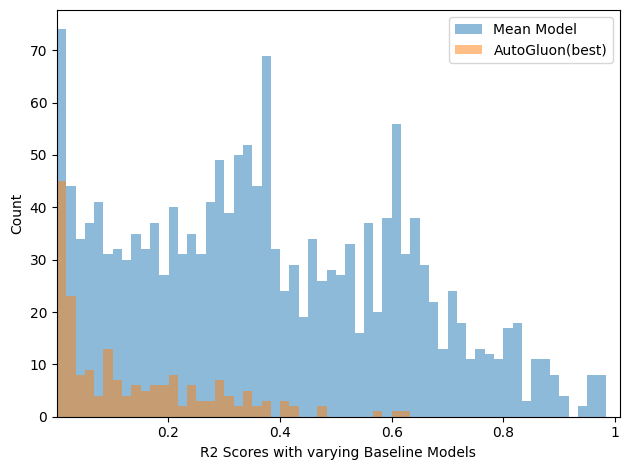

In [18]:
import numpy as np
import matplotlib.pyplot as plt

x1 = df_vm.loc[:, "R2 (mean)"]
x2 = df_vm.loc[:, "R2 (AG best)"]


# clip data
xmin = 0.0001

# bins from -1 to 1
bins = np.linspace(xmin, 1.0, 61)
w = bins[1] - bins[0]

# split only on upper overflow
x1_le = x1[x1 <= 1.0]
x2_le = x2[x2 <= 1.0]
x1_over = x1[x1 > 1.0]
x2_over = x2[x2 > 1.0]

fig, ax = plt.subplots()

ax.hist(x1_le, bins=bins, alpha=0.5, label="Mean Model")
ax.hist(x2_le, bins=bins, alpha=0.5, label="AutoGluon(best)")

# overflow bar centered on 1.0
ax.bar(1.0, len(x1_over), width=0.9 * w, alpha=0.5)
ax.bar(1.0, len(x2_over), width=0.9 * w, alpha=0.5)

# explicit ticks: drop everything >1
ticks = [t for t in ax.get_xticks() if t < 1.0]
ticks.append(1.0)

ax.set_xticks(ticks)
ax.set_xticklabels([f"{t:g}" if t < 1.0 else "1" for t in ticks])
ax.set_xlim(xmin, 1.0 + 0.5 * w)
ax.legend()
ax.set_xlabel(f"R2 Scores with varying Baseline Models") #Dropped Poor Performing ones
ax.set_ylabel("Count")
fig.tight_layout()
plt.savefig(f"./cache/R2_score_histogram.pdf")
plt.show()

## Recommentations
- Only consider significant wins when counting wins against AG -- as AG is good at representing the difficulty of a dataset not the SOTA for a dataset
- Compute R2 with AG as baseline is more meaningful than with MeanModel
- Use several Datasets for comparisons outliers are unavoidable
- Also consider the Mean Model regardless, because some tasks might be truly novel and unpredictable with standard methods like AG but such scenarios are rare and hence AG should still be the main baseline

# Critical Difference Diagrams

In [28]:
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare
from aeon.visualisation import plot_critical_difference
metric = "root_mean_squared_error"
db_mode = "ctr" # "vimet" or "ctr"

In [29]:
if db_mode == "vimet":
    conn = sqlite3.connect(vimet_path)
else:
    conn = sqlite3.connect(ctr_path)
df = pd.read_sql(f"SELECT results.model as model, search_space_name as Model, {metric}, mean_squared_error, data_config_hash, data_id FROM results join search_spaces on results.search_space_hash == search_spaces.hash_key", conn)
conn.close()
df['Model'] = df['Model'].str.replace(r'^(.*?)_(.*)$', r'\1(\2)', regex=True)
df = df[df["Model"].isin(common)].copy()


df = convert_listlike_cols(df)

# remove duplicates
df = df.drop_duplicates(subset=['Model', 'data_id', 'data_config_hash'], keep='first')

# keep only models with a failure rate below 20% (anything above that cannot be used for meaningfull comparisons)
successrate_threshold = len(df["data_id"].unique()) * 0.8
vc = df['Model'].value_counts()
df = df[df['Model'].isin(vc[vc >= successrate_threshold].index)]

df[metric] = df[f"{metric}_corrected"]
df[metric] = df[metric].apply(
    lambda x: sum(x) / len(x) if x else None
)

df['Model'].value_counts()

root_mean_squared_error
mean_squared_error


Model
AdaBoost               35
LightGBM               35
AutoGluon(1h)          35
AutoGluon(30min)       35
XGBoost                35
SGD                    35
RidgeRegressor         35
PassiveAggressive      35
PartialLeastSquares    35
MedianModel            35
Bagging                35
MeanModel              35
AutoGluon(2h)          35
KNN                    35
GradientBoosting       35
Huber                  35
BayesianRidge          35
DecisionTree           35
CatBoost               35
Lasso                  35
ElasticNet             35
Dummy                  35
AutoGluon(5min)        34
AutoGluon(10min)       34
LassoLars              34
ExtraTrees             34
MLP                    33
M5                     33
RandomForest           33
Name: count, dtype: int64

In [30]:
data = {
    "Datasets": [grouping for grouping, _ in df.groupby(by=["data_config_hash", "data_id"])],
    "Algorithms": list(df["Model"].unique())
}

errors = []
for data_hash, data_id in data["Datasets"]:
    dataset_errors = []
    df_ = df[(df["data_config_hash"] == data_hash) & (df["data_id"] == data_id)]
    minimum = df_[metric].min()
    for algo in data["Algorithms"]:
        algo_perf = df_[df_["Model"] == algo]
        if len(algo_perf) > 0:
            # print(algo_perf)
            algo_perf = algo_perf[metric].iloc[0]
        else: 
            algo_perf = minimum
        dataset_errors.append(algo_perf)
    errors.append(dataset_errors)
data['Performance (Error)'] = errors
data['Performance (Error)']

[[2.2352921481829267,
  2.3788321970495696,
  2.230391710994842,
  2.4500683954897315,
  3.2215586757855283,
  2.234122285869458,
  2.189254451156698,
  2.165257343850785,
  2.233410289393773,
  2.187351588686449,
  2.1505272743356394,
  2.252129414491619,
  2.231579031955547,
  2.1556834712246227,
  3.2215586757855283,
  3.319603551307137,
  2.2455586857266496,
  3.8789491637660825,
  2.1770934465810425,
  2.2327341754979813,
  2.137409559500499,
  2.3048500171316526,
  2.159300136566162,
  2.155316389139442,
  2.1119515776634215,
  2.0929279685020448,
  2.071598768234253,
  2.0633246064186097,
  2.058794319629669],
 [1.963789525427427,
  5.14413281405154,
  4.822697025198544,
  2.498407462492571,
  6.8948687046297605,
  4.822673201814167,
  1.4051294608721987,
  1.3908707910846085,
  5.468948100995077,
  1.4142855329127362,
  5.846674563888344,
  4.823321315850033,
  4.823081733161809,
  1.3541105321373244,
  6.8948687046297605,
  6.949759667341309,
  4.83398938541056,
  139.37924844

In [31]:
# Convert the data into a DataFrame
datasets = data['Datasets']
algorithms = data['Algorithms']
performance_data = data['Performance (Error)']

# Create a list of dictionaries for each dataset
rows = []
for dataset, performance in zip(datasets, performance_data):
    row = {'Dataset': dataset}
    row.update({alg: perf for alg, perf in zip(algorithms, performance)})
    rows.append(row)

# Create the DataFrame
df = pd.DataFrame(rows)

# Calculate the ranking of each algorithm for each dataset
rankings_matrix = df[algorithms].rank(axis=1, method='average', ascending=False)

df

,Dataset,AdaBoost,Bagging,BayesianRidge,DecisionTree,Dummy,ElasticNet,CatBoost,ExtraTrees,Huber,...,RidgeRegressor,RandomForest,SGD,XGBoost,MLP,AutoGluon(5min),AutoGluon(10min),AutoGluon(30min),AutoGluon(1h),AutoGluon(2h)
0,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,2.235292,2.378832,2.230392,2.450068,3.221559,2.234122,2.189254,2.165257,2.233410,...,2.232734,2.137410,2.304850e+00,2.159300,2.155316,2.111952,2.092928,2.071599,2.063325,2.058794
1,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,1.963790,5.144133,4.822697,2.498407,6.894869,4.822673,1.405129,1.390871,5.468948,...,4.823331,1.704908,1.379427e+01,1.428045,25.549486,1.227264,1.182780,1.136395,1.104901,1.067739
2,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,798.721602,7469.138876,8175.259239,1157.593343,10364.017334,8227.726731,675.945867,2418.215159,8232.486135,...,8173.188893,1626.764190,8.799434e+03,482.574979,7223.697814,482.763530,296.154649,254.928722,241.319733,232.665587
3,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,5.014515,10.424456,10.442514,6.878200,16.715189,11.233960,3.918917,4.607777,10.481111,...,10.869614,4.729673,1.586636e+01,4.331674,6.937675,3.856331,3.785376,3.728149,3.745953,3.743402
4,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,3.467909,4.150803,5.184952,4.519214,6.118141,5.184995,3.503427,3.395509,5.688033,...,5.184848,3.444698,3.648425e+08,3.652435,37.938286,3.456127,3.462725,3.262126,3.231843,3.206869
5,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,9.672227,9.644313,17.639276,11.724098,34.250675,17.688668,9.133530,9.028652,20.312577,...,17.630108,9.216921,2.389861e+01,9.464263,16.881510,9.343450,9.214566,8.936200,8.935778,8.882554
6,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,15.750551,17.010043,16.677440,20.500119,18.417253,16.698511,15.619406,15.309098,16.911387,...,16.825108,15.655829,1.705701e+01,15.891785,16.712948,15.139021,15.024115,14.935072,14.983115,14.934711
7,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,0.800583,0.771719,0.770436,0.832002,0.823323,0.770133,0.807993,0.815328,0.772210,...,0.772789,0.798992,7.973029e-01,0.778711,0.824261,0.767626,0.772037,0.757168,0.766384,0.769597
8,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,0.000884,0.001309,0.005838,0.001551,0.014719,0.007344,0.000756,0.000651,0.018489,...,0.005854,0.000886,1.563694e-02,0.010315,2.675068,0.000494,0.000434,0.000399,0.000327,0.000317
9,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,0.629059,0.648325,0.756650,0.787857,0.885355,0.757930,0.590662,0.572779,0.757179,...,0.754312,0.592146,8.497371e-01,0.609768,0.762007,0.585281,0.590600,0.579858,0.578565,0.578314


In [32]:
# Format the results
formatted_results = df[algorithms].copy()
for col in formatted_results.columns:
    formatted_results[col] = formatted_results[col].round(3).astype(str) + " (" + rankings_matrix[col].astype(int).astype(str) + ")"

# Add a row for the sum of ranks and average of ranks
sum_ranks = rankings_matrix.sum().round(3).rename('Sum Ranks')
average_ranks = rankings_matrix.mean().round(3).rename('Average Ranks')

# Add the rows to the formatted DataFrame using concat
formatted_results = pd.concat([formatted_results, sum_ranks.to_frame().T, average_ranks.to_frame().T])

# Add the 'Dataset' column to the formatted DataFrame
formatted_results.insert(0, 'Dataset', df['Dataset'].tolist() + ['Sum Ranks', 'Average Ranks'])

formatted_results

,Dataset,AdaBoost,Bagging,BayesianRidge,DecisionTree,Dummy,ElasticNet,CatBoost,ExtraTrees,Huber,...,RidgeRegressor,RandomForest,SGD,XGBoost,MLP,AutoGluon(5min),AutoGluon(10min),AutoGluon(30min),AutoGluon(1h),AutoGluon(2h)
0,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,2.235 (10),2.379 (6),2.23 (15),2.45 (5),3.222 (3),2.234 (11),2.189 (16),2.165 (19),2.233 (12),...,2.233 (13),2.137 (24),2.305 (7),2.159 (20),2.155 (22),2.112 (25),2.093 (26),2.072 (27),2.063 (28),2.059 (29)
1,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,1.964 (17),5.144 (9),4.823 (14),2.498 (16),6.895 (5),4.823 (15),1.405 (22),1.391 (23),5.469 (8),...,4.823 (11),1.705 (18),13.794 (3),1.428 (20),25.549 (2),1.227 (25),1.183 (26),1.136 (27),1.105 (28),1.068 (29)
2,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,798.722 (21),7469.139 (13),8175.259 (9),1157.593 (18),10364.017 (3),8227.727 (7),675.946 (22),2418.215 (16),8232.486 (6),...,8173.189 (12),1626.764 (17),8799.434 (5),482.575 (24),7223.698 (14),482.764 (23),296.155 (26),254.929 (27),241.32 (28),232.666 (29)
3,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,5.015 (17),10.424 (13),10.443 (12),6.878 (16),16.715 (2),11.234 (6),3.919 (24),4.608 (20),10.481 (10),...,10.87 (9),4.73 (19),15.866 (4),4.332 (21),6.938 (15),3.856 (25),3.785 (26),3.728 (29),3.746 (27),3.743 (28)
4,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,3.468 (21),4.151 (16),5.185 (11),4.519 (15),6.118 (5),5.185 (10),3.503 (20),3.396 (26),5.688 (7),...,5.185 (14),3.445 (25),364842523.711 (1),3.652 (18),37.938 (2),3.456 (24),3.463 (23),3.262 (27),3.232 (28),3.207 (29)
5,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,9.672 (16),9.644 (17),17.639 (10),11.724 (14),34.251 (2),17.689 (8),9.134 (25),9.029 (26),20.313 (6),...,17.63 (11),9.217 (23),23.899 (5),9.464 (19),16.882 (13),9.343 (20),9.215 (24),8.936 (27),8.936 (28),8.883 (29)
6,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,15.751 (20),17.01 (7),16.677 (15),20.5 (1),18.417 (4),16.699 (13),15.619 (22),15.309 (24),16.911 (8),...,16.825 (10),15.656 (21),17.057 (6),15.892 (19),16.713 (11),15.139 (25),15.024 (26),14.935 (28),14.983 (27),14.935 (29)
7,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,0.801 (10),0.772 (20),0.77 (22),0.832 (4),0.823 (6),0.77 (23),0.808 (9),0.815 (8),0.772 (18),...,0.773 (17),0.799 (12),0.797 (13),0.779 (16),0.824 (5),0.768 (27),0.772 (19),0.757 (29),0.766 (28),0.77 (25)
8,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,0.001 (21),0.001 (17),0.006 (14),0.002 (16),0.015 (6),0.007 (10),0.001 (22),0.001 (23),0.018 (3),...,0.006 (13),0.001 (20),0.016 (4),0.01 (8),2.675 (1),0.0 (24),0.0 (25),0.0 (26),0.0 (27),0.0 (28)
9,(2a5bb20661bcb64796e2f4f2eb847266e7feb6cedf57a...,0.629 (17),0.648 (16),0.757 (12),0.788 (6),0.885 (3),0.758 (9),0.591 (23),0.573 (29),0.757 (11),...,0.754 (14),0.592 (22),0.85 (5),0.61 (18),0.762 (7),0.585 (25),0.591 (24),0.58 (26),0.579 (27),0.578 (28)


In [33]:
# Perform the Friedman Test
friedman_stat, p_value = friedmanchisquare(*rankings_matrix.T.values)
print(f"Friedman test statistic: {friedman_stat}, p-value = {p_value}")

# Convert the accuracy matrix into a NumPy array for the critical difference diagram
scores = df[algorithms].values
classifiers = df[algorithms].columns.tolist()

#scores[scores<0] = 0
scores

Friedman test statistic: 687.4199012891553, p-value = 8.347869665313051e-127


array([[2.23529215e+00, 2.37883220e+00, 2.23039171e+00, ...,
        2.07159877e+00, 2.06332461e+00, 2.05879432e+00],
       [1.96378953e+00, 5.14413281e+00, 4.82269703e+00, ...,
        1.13639546e+00, 1.10490076e+00, 1.06773862e+00],
       [7.98721602e+02, 7.46913888e+03, 8.17525924e+03, ...,
        2.54928722e+02, 2.41319733e+02, 2.32665587e+02],
       ...,
       [9.08802933e-01, 1.04673016e+00, 9.55824695e-01, ...,
        8.62749728e-01, 8.68183915e-01, 8.58239457e-01],
       [2.59170752e+03, 3.84769290e+03, 2.94462281e+03, ...,
        2.08778091e+03, 2.10802710e+03, 2.06588077e+03],
       [1.17722994e-01, 1.48625044e-01, 1.28599561e-01, ...,
        9.94235886e-02, 9.82913755e-02, 9.55083834e-02]])

c:\Users\poehlmann\PycharmProjects\AutoViMet\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:600: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  return result_to_tuple(hypotest_fun_out(*samples, **kwds))


<Figure size 1600x2000 with 0 Axes>

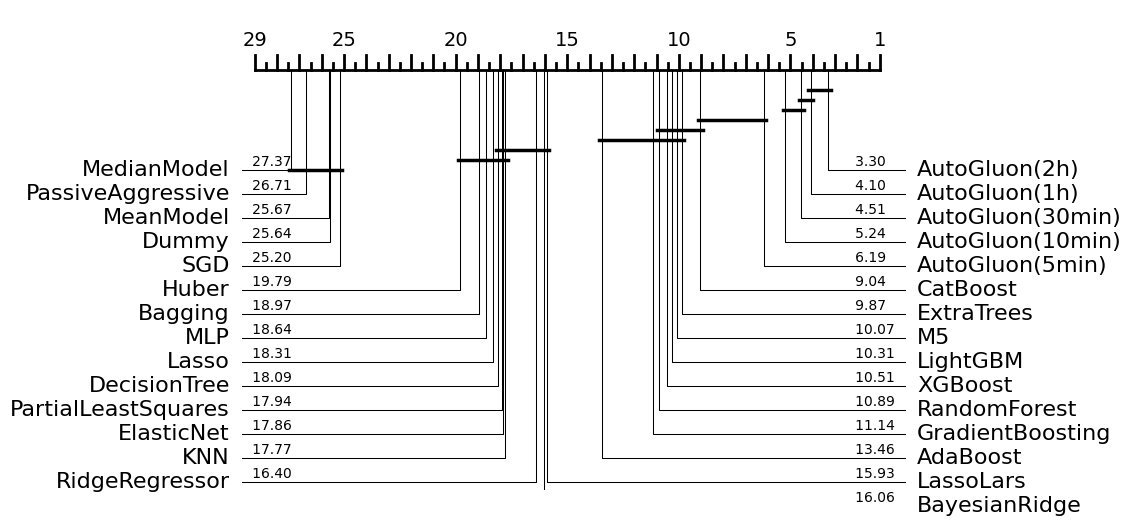

In [34]:
# Set the figure size before plotting
plt.figure(figsize=(16, 20))  # Adjust the figure size as needed

# Generate the critical difference diagram
fig, _ = plot_critical_difference(
    scores, 
    classifiers, 
    lower_better=not larger_is_better,
    test='wilcoxon',  # or nemenyi
    correction='holm', # or bonferroni or none
    alpha=0.05,
    width=7,
    textspace=1
)

# Get the current axes
ax = plt.gca()

# Adjust font size and rotation of x-axis labels
for label in ax.get_xticklabels():
    label.set_fontsize(14) 
    label.set_rotation(45) 
    label.set_horizontalalignment('right')

# Increase padding between labels and axis
ax.tick_params(axis='x', which='major', pad=20)

# Adjust margins to provide more space for labels
plt.subplots_adjust(bottom=0.1)

# Optionally adjust y-axis label font size
ax.tick_params(axis='y', labelsize=font_size)

# Save and display the plot
for txt in ax.texts:
    if txt.get_text().isdigit():   
        # Reduce Overcrowded X-Axis
        if int(txt.get_text()) % 5 != 0 and (int(txt.get_text()) not in (len(classifiers), 1)):
            txt.set_visible(False)
        else:
            txt.set_fontsize(font_size)
    else:
        # Round Rankings
        try: 
            value = float(txt.get_text())
            txt.set_text(f"   {value:.2f}   ")
            #txt.set_fontsize(font_size)
        except:
            pass


plt.savefig(f'critical_difference_diagram_{db_mode}.pdf', format="pdf", bbox_inches="tight", pad_inches=0.5, dpi=900)
plt.show()

# Raw Ranking Matrix
\begin{sidewaystable}

In [21]:
conn_vimet = sqlite3.connect(vimet_path)
df_vimet = pd.read_sql(f"SELECT results.model as model, search_space_name as Model, {METRIC}, mean_squared_error, data_config_hash, data_id FROM results join search_spaces on results.search_space_hash == search_spaces.hash_key", conn_vimet)
conn_vimet.close()
df_vimet['Model'] = df_vimet['Model'].str.replace(r'^(.*?)_(.*)$', r'\1(\2)', regex=True)
df_vimet = convert_listlike_cols(df_vimet)

# remove duplicates
df_vimet = df_vimet.drop_duplicates(subset=['Model', 'data_id', 'data_config_hash'], keep='first')

# keep only models with a failure rate below 20% (anything above that cannot be used for meaningfull comparisons)
successrate_threshold = len(df_vimet["data_id"].unique()) * 0.8
vc = df_vimet['Model'].value_counts()
df_vimet = df_vimet[df_vimet['Model'].isin(vc[vc >= successrate_threshold].index)]

df_vimet['Model'].value_counts()

root_mean_squared_error
mean_squared_error


Model
AdaBoost               102
Bagging                102
MeanModel              102
AutoGluon(30min)       102
AutoGluon(2h)          102
AutoGluon(1h)          102
AutoGluon(10min)       102
XGBoost                102
RandomForest           102
RidgeRegressor         102
SGD                    102
MLP                    102
PassiveAggressive      102
M5                     102
LightGBM               102
PartialLeastSquares    102
Lasso                  102
KNN                    102
Huber                  102
LassoLars              102
GradientBoosting       102
ExtraTrees             102
ElasticNet             102
Dummy                  102
DecisionTree           102
BayesianRidge          102
MedianModel            102
AutoGluon(5min)        100
CatBoost               100
Name: count, dtype: int64

In [22]:
conn_ctr = sqlite3.connect(ctr_path)
df_ctr = pd.read_sql(f"SELECT results.model as model, search_space_name as Model, {METRIC}, mean_squared_error, data_config_hash, data_id FROM results join search_spaces on results.search_space_hash == search_spaces.hash_key", conn_ctr)
conn_ctr.close()
df_ctr['Model'] = df_ctr['Model'].str.replace(r'^(.*?)_(.*)$', r'\1(\2)', regex=True)
df_ctr = convert_listlike_cols(df_ctr)

# remove duplicates
df_ctr = df_ctr.drop_duplicates(subset=['Model', 'data_id', 'data_config_hash'], keep='first')

# keep only models with a failure rate below 20% (anything above that cannot be used for meaningfull comparisons)
successrate_threshold = len(df_ctr["data_id"].unique()) * 0.8
vc = df_ctr['Model'].value_counts()
df_ctr = df_ctr[df_ctr['Model'].isin(vc[vc >= successrate_threshold].index)]

df_ctr['Model'].value_counts()

root_mean_squared_error
mean_squared_error


Model
AdaBoost               35
LightGBM               35
AutoGluon(1h)          35
AutoGluon(30min)       35
AutoGluon(1min)        35
XGBoost                35
GaussianProcess        35
SGD                    35
RidgeRegressor         35
PassiveAggressive      35
PartialLeastSquares    35
Bagging                35
MeanModel              35
MedianModel            35
ElasticNet             35
CatBoost               35
BayesianRidge          35
DecisionTree           35
Dummy                  35
Lasso                  35
AutoGluon(2h)          35
Huber                  35
GradientBoosting       35
KNN                    35
ExtraTrees             34
AutoGluon(5min)        34
AutoGluon(10min)       34
CubistModel            34
LARS                   34
LassoLars              34
RandomForest           33
M5                     33
MLP                    33
Tweedie                29
Name: count, dtype: int64

In [23]:
# get common model values
common = set(df_ctr["Model"]).intersection(df_vimet["Model"])

# filter both dataframes
df_ctr = df_ctr[df_ctr["Model"].isin(common)].copy()
df_vimet = df_vimet[df_vimet["Model"].isin(common)].copy()
df_ctr['Model'].value_counts()

Model
AdaBoost               35
LightGBM               35
AutoGluon(1h)          35
AutoGluon(30min)       35
XGBoost                35
SGD                    35
RidgeRegressor         35
PassiveAggressive      35
PartialLeastSquares    35
MedianModel            35
Bagging                35
MeanModel              35
AutoGluon(2h)          35
KNN                    35
GradientBoosting       35
Huber                  35
BayesianRidge          35
DecisionTree           35
CatBoost               35
Lasso                  35
ElasticNet             35
Dummy                  35
AutoGluon(5min)        34
AutoGluon(10min)       34
LassoLars              34
ExtraTrees             34
MLP                    33
M5                     33
RandomForest           33
Name: count, dtype: int64

In [24]:
def calc_ranking(df):
    groups = df.groupby(by=["data_config_hash", "data_id"])
    raw_rankings = []
    rounded_rankings = []
    
    for (hash, data_id), group_df in tqdm(groups):
        # Add AutoGluon(best) to group
        if larger_is_better:
            best_idx = (
                group_df.loc[group_df["model"] == "AutoGluon", "avg_metric"]
                .idxmax()
            )
            worst_idx = (
                group_df.loc[group_df["model"] == "AutoGluon", "avg_metric"]
                .idxmin()
            )
        else:
            best_idx = (
                group_df.loc[group_df["model"] == "AutoGluon", "avg_metric"]
                .idxmin()
            )
            worst_idx = (
                group_df.loc[group_df["model"] == "AutoGluon", "avg_metric"]
                .idxmax()
            )
            # AG+Mean(Best)
            best_mean_ag_idx = (
                group_df.loc[group_df["model"].isin(["AutoGluon", "MeanModel"]), "avg_metric"]
                .idxmin()
            )
        best_ag_model = group_df.loc[best_idx].copy()
        worst_ag_model = group_df.loc[worst_idx].copy()
        best_mean_ag_model = group_df.loc[best_mean_ag_idx].copy()
        best_ag_model["Model"] = "AutoGluon(best)"
        worst_ag_model["Model"] = "AutoGluon(worst)"
        best_mean_ag_model["Model"] = "AutoGluon/Mean(best)"
        # ! Stupid group_df = pd.concat([group_df, pd.DataFrame([best_ag_model]), pd.DataFrame([worst_ag_model])], ignore_index=True)

        ag_id = group_df[group_df["model"] == "AutoGluon"].index[0]
        median_ag_model = group_df.loc[ag_id].copy() # Load Template (Doesnt matter which id as long as its AutoGluon)
        median_ag_model["Model"] = "AutoGluon(median)"
        median_ag_model["avg_metric"] = group_df.loc[group_df["model"] == "AutoGluon", "avg_metric"].median() 
        median_ag_model["MSE"] = group_df.loc[group_df["model"] == "AutoGluon", "MSE"].median()
        group_df = pd.concat([group_df, pd.DataFrame([median_ag_model]), pd.DataFrame([best_ag_model]), pd.DataFrame([worst_ag_model]), pd.DataFrame([best_mean_ag_model])], ignore_index=True)
        
        if larger_is_better:
            best = group_df["avg_metric"].max()
        else:
            best = group_df["avg_metric"].min()

        median = group_df["avg_metric"].median()

        if METRIC == "r2_score":
            if best <= 0.001:
                group_df["normalized_metric"] = 0 # If all fail, all fail simple as that
            else:
                group_df["normalized_metric"] = (group_df["avg_metric"] - median) / max(best-median, 1e-5)
        else:
            if larger_is_better:
                group_df["normalized_metric"] = (group_df["avg_metric"] - median) / max(best-median, 1e-5) #TODO what happens when negative
            else:
                group_df["normalized_metric"] = (group_df["avg_metric"] - best) / max(median-best, 1e-5)

        group_df["rounded_rank"] = group_df["normalized_metric"].round(2).rank(method="dense", ascending=not larger_is_better)
        group_df["raw_rank"] = group_df["avg_metric"].rank(method="dense", ascending=not larger_is_better)
        group_df["data_id"] = data_id
        raw_rankings.append(group_df[["Model", "raw_rank", "data_id"]].rename(columns={"raw_rank": "Rank"}))
        rounded_rankings.append(group_df[["Model", "rounded_rank", "data_id"]].rename(columns={"rounded_rank": "Rank"}))
    
    raw_rankings_df = pd.concat(raw_rankings, ignore_index=True)
    rounded_rankings_df = pd.concat(rounded_rankings, ignore_index=True)

    raw_rankings_pivot = raw_rankings_df.pivot_table(index="Model", columns="data_id", values="Rank")
    rounded_rankings_pivot = rounded_rankings_df.pivot_table(index="Model", columns="data_id", values="Rank")

    return raw_rankings_pivot, rounded_rankings_pivot

df_vimet["avg_metric"] = compute_mean(df_vimet[METRIC])
df_vimet["MSE"] = compute_mean(df_vimet["mean_squared_error"])
df_vimet = df_vimet.dropna(subset=["avg_metric"], how='all')

df_ctr["avg_metric"] = compute_mean(df_ctr[METRIC])
df_ctr["MSE"] = compute_mean(df_ctr["mean_squared_error"])
df_ctr = df_ctr.dropna(subset=["avg_metric"], how='all')

raw_ranks_ctr, rounded_ranks_ctr = calc_ranking(df_ctr)
raw_ranks_vimet, rounded_ranks_vimet = calc_ranking(df_vimet)

rankings = {
        "CTR23 Raw": raw_ranks_ctr,
        "CTR23 Rounded": rounded_ranks_ctr,
        "ViMet Raw": raw_ranks_vimet,
        "ViMet Rounded": rounded_ranks_vimet,
    }


def pretty_rank(x, value_name, worst_val, best_val, color=True):
    is_missing = pd.isna(x[value_name])
    rank = worst_val if is_missing else x[value_name]

    content = r"\NA " if is_missing else bold_if(int(rank), 1)

    if color and best_val != worst_val:
        if best_val > worst_val:
            pct = 100 * (rank - worst_val) / (best_val - worst_val)
        else:
            pct = 100 - 100 * (rank - best_val) / (worst_val - best_val)

        rgba = _magma_rgba(pct)
        hex_color = _rgba_to_hex(rgba)
        font_color = _font_color_from_rgba(rgba)

        return rf"\cellcolor[HTML]{{{hex_color}}}\textcolor{{{font_color}}}{{{content}}}"

    return content





for name, ranking in rankings.items():
    for col in ranking.columns:
        worst_rank = ranking[col].max()
        best_rank = ranking[col].min()
        ranking[col] = ranking.apply(lambda x: pretty_rank(x, col, worst_rank, best_rank), axis=1)
    ranking = ranking.loc[[v for k in row_grouping.keys() for v in row_grouping[k] if v in ranking.index]]
    rankings[name] = ranking

rankings["CTR23 Rounded"]

100%|██████████| 102/102 [00:00<00:00, 147.91it/s]


data_id,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
Model,,,,,,,,,,,,,,,,,,,,,
MeanModel,\cellcolor[HTML]{0E0B2B}\textcolor{white}{24},\cellcolor[HTML]{2F1163}\textcolor{white}{20},\cellcolor[HTML]{120D31}\textcolor{white}{21},\cellcolor[HTML]{0D0A29}\textcolor{white}{25},\cellcolor[HTML]{36106B}\textcolor{white}{18},\cellcolor[HTML]{060518}\textcolor{white}{23},\cellcolor[HTML]{1A1042}\textcolor{white}{23},\cellcolor[HTML]{38106C}\textcolor{white}{22},\cellcolor[HTML]{29115A}\textcolor{white}{22},\cellcolor[HTML]{100B2D}\textcolor{white}{23},...,\cellcolor[HTML]{36106B}\textcolor{white}{18},\cellcolor[HTML]{140E36}\textcolor{white}{19},\cellcolor[HTML]{120D31}\textcolor{white}{21},\cellcolor[HTML]{050416}\textcolor{white}{24},\cellcolor[HTML]{060518}\textcolor{white}{22},\cellcolor[HTML]{FEAC76}\textcolor{black}{5},\cellcolor[HTML]{0D0A29}\textcolor{white}{25},\cellcolor[HTML]{050416}\textcolor{white}{24},\cellcolor[HTML]{38106C}\textcolor{white}{22},\cellcolor[HTML]{4A1079}\textcolor{white}{17}
MedianModel,\cellcolor[HTML]{050416}\textcolor{white}{25},\cellcolor[HTML]{1E1149}\textcolor{white}{21},\cellcolor[HTML]{000004}\textcolor{white}{23},\cellcolor[HTML]{000004}\textcolor{white}{27},\cellcolor[HTML]{221150}\textcolor{white}{19},\cellcolor[HTML]{000004}\textcolor{white}{24},\cellcolor[HTML]{050416}\textcolor{white}{25},\cellcolor[HTML]{040414}\textcolor{white}{26},\cellcolor[HTML]{29115A}\textcolor{white}{22},\cellcolor[HTML]{050416}\textcolor{white}{24},...,\cellcolor[HTML]{221150}\textcolor{white}{19},\cellcolor[HTML]{000004}\textcolor{white}{21},\cellcolor[HTML]{060518}\textcolor{white}{22},\cellcolor[HTML]{000004}\textcolor{white}{25},\cellcolor[HTML]{000004}\textcolor{white}{23},\cellcolor[HTML]{9B2E7F}\textcolor{white}{14},\cellcolor[HTML]{19103F}\textcolor{white}{24},\cellcolor[HTML]{000004}\textcolor{white}{25},\cellcolor[HTML]{271258}\textcolor{white}{23},\cellcolor[HTML]{36106B}\textcolor{white}{18}
Dummy,\cellcolor[HTML]{0E0B2B}\textcolor{white}{24},\cellcolor[HTML]{2F1163}\textcolor{white}{20},\cellcolor[HTML]{120D31}\textcolor{white}{21},\cellcolor[HTML]{040414}\textcolor{white}{26},\cellcolor[HTML]{36106B}\textcolor{white}{18},\cellcolor[HTML]{060518}\textcolor{white}{23},\cellcolor[HTML]{1A1042}\textcolor{white}{23},\cellcolor[HTML]{38106C}\textcolor{white}{22},\cellcolor[HTML]{29115A}\textcolor{white}{22},\cellcolor[HTML]{100B2D}\textcolor{white}{23},...,\cellcolor[HTML]{36106B}\textcolor{white}{18},\cellcolor[HTML]{140E36}\textcolor{white}{19},\cellcolor[HTML]{120D31}\textcolor{white}{21},\cellcolor[HTML]{100B2D}\textcolor{white}{23},\cellcolor[HTML]{060518}\textcolor{white}{22},\cellcolor[HTML]{FDE9AA}\textcolor{black}{2},\cellcolor[HTML]{040414}\textcolor{white}{26},\cellcolor[HTML]{000004}\textcolor{white}{25},\cellcolor[HTML]{19103F}\textcolor{white}{24},\cellcolor[HTML]{4A1079}\textcolor{white}{17}
RidgeRegressor,\cellcolor[HTML]{8C2981}\textcolor{white}{16},\cellcolor[HTML]{892881}\textcolor{white}{15},\cellcolor[HTML]{6B1D81}\textcolor{white}{16},\cellcolor[HTML]{671B80}\textcolor{white}{19},\cellcolor[HTML]{721F81}\textcolor{white}{15},\cellcolor[HTML]{782281}\textcolor{white}{16},\cellcolor[HTML]{6B1D81}\textcolor{white}{18},\cellcolor[HTML]{D5446D}\textcolor{white}{12},\cellcolor[HTML]{8C2981}\textcolor{white}{16},\cellcolor[HTML]{A5317E}\textcolor{white}{14},...,\cellcolor[HTML]{842681}\textcolor{white}{14},\cellcolor[HTML]{A1307E}\textcolor{white}{12},\cellcolor[HTML]{471078}\textcolor{white}{18},\cellcolor[HTML]{FCFDBF}\textcolor{black}{\tex...,\cellcolor[HTML]{7E2482}\textcolor{white}{15},\cellcolor[HTML]{FB835F}\textcolor{white}{7},\cellcolor[HTML]{FA7F5E}\textcolor{white}{8},\cellcolor[HTML]{B73779}\textcolor{white}{13},\cellcolor[HTML]{A6317D}\textcolor{white}{15},\cellcolor[HTML]{AB337C}\textcolor{white}{12}
Lasso,\cellcolor[HTML]{4C117A}\textcolor{white}{20},\cellcolor[HTML]{892881}\textcolor{white}{15},\cellcolor[HTML]{6B1D81}\textcolor{white}{16},\cellcolor[HTML]{491078}\tex

In [26]:
latex = df_to_ml_latex_table(rankings["CTR23 Raw"], caption=f"Ranking Matrix across CTR23 benchmark, based on raw {PRETTY_METRIC}.", label="tab:ctr_ranks_raw", siunitx=False)
print(latex)

\begin{table*}[t]
\centering
\caption{Ranking Matrix across CTR23 benchmark, based on raw RMSE.}\label{tab:ctr_ranks_raw}
\setlength{\tabcolsep}{4.0pt}
\renewcommand{\arraystretch}{1.15}
\small
\resizebox{\linewidth}{!}{%
\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
Model & 0 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 9 & 10 & 11 & 12 & 13 & 14 & 15 & 16 & 17 & 18 & 19 & 20 & 21 & 22 & 23 & 24 & 25 & 26 & 27 & 28 & 29 & 30 & 31 & 32 & 33 & 34 \\
\midrule
MeanModel & \cellcolor[HTML]{0C0926}\textcolor{white}{26} & \cellcolor[HTML]{241253}\textcolor{white}{24} & \cellcolor[HTML]{0C0926}\textcolor{white}{26} & \cellcolor[HTML]{0C0926}\textcolor{white}{27} & \cellcolor[HTML]{241253}\textcolor{white}{24} & \cellcolor[HTML]{040414}\textcolor{white}{27} & \cellcolor[HTML]{180F3D}\textcolor{white}{25} & \cellcolor[HTML]{341069}\textcolor{white}{23} & \cellcolor[HTML]{221150}\textcolor{white}{25} & \cellcolor[HTML]{0C0926}\textcolor{white}{26} & \cellcolor[HTML]{0C0926}\textcolor{white

In [27]:
latex = df_to_ml_latex_table(rankings["ViMet Raw"], tabcolsep_pt=2, transpose=True, caption=f"Ranking Matrix across \\vm benchmark, based on raw {PRETTY_METRIC}.", label="tab:vimet_ranks_raw", siunitx=False)
print(latex)

\onecolumn
\setlength{\tabcolsep}{2pt}
\small
\begin{longtable}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\caption{Ranking Matrix across \vm benchmark, based on raw RMSE.}\label{tab:vimet_ranks_raw} \\
\toprule
Dataset & \rotatebox{90}{MeanModel} & \rotatebox{90}{MedianModel} & \rotatebox{90}{Dummy} & \rotatebox{90}{RidgeRegressor} & \rotatebox{90}{Lasso} & \rotatebox{90}{LassoLars} & \rotatebox{90}{ElasticNet} & \rotatebox{90}{Huber} & \rotatebox{90}{BayesianRidge} & \rotatebox{90}{PassiveAggressive} & \rotatebox{90}{SGD} & \rotatebox{90}{PartialLeastSquares} & \rotatebox{90}{KNN} & \rotatebox{90}{MLP} & \rotatebox{90}{Bagging} & \rotatebox{90}{RandomForest} & \rotatebox{90}{ExtraTrees} & \rotatebox{90}{DecisionTree} & \rotatebox{90}{M5} & \rotatebox{90}{GradientBoosting} & \rotatebox{90}{AdaBoost} & \rotatebox{90}{XGBoost} & \rotatebox{90}{LightGBM} & \rotatebox{90}{CatBoost} & \rotatebox{90}{AutoGluon(5min)} & \rotatebox{90}{AutoGluon(10min)} & \rotatebox{90}{AutoGluon(30min)} & \rotatebox

In [35]:
rankings["CTR23 Rounded"].index.name

'Model'